In [ ]:
"""
ChargeStationMakale_RoadAware.py

Road-attribute-aware EV route planning experiment pipeline.

Main changes in this version:
1. Real OpenStreetMap EV charging stations are used via amenity=charging_station.
2. OSMnx-derived/imputed speed_kph and travel_time attributes are added to road-network edges.
3. A road-attribute-aware energy model is added:
   - distance-only model is preserved as an option,
   - road-attribute model uses edge length, speed factor, and highway/road-type factor.
4. Travel-time metrics are added to all route simulations and summaries.
5. Classical baselines use selected energy model for feasibility checks:
   - Shortest Path without charging
   - Shortest Path with passive charging
   - Greedy nearest reachable charging
   - Energy-aware charging detour
6. Q-learning remains node-aware:
   - state key includes current_node, battery_bin, and active_goal_node
   - actions are valid neighboring nodes only
7. Metrics remain corrected:
   - success_rate is computed over all scenarios
   - route length/deviation/travel time are summarized only for successful routes
   - traveled distance/time are retained for failed runs
"""

# ============================================================
# 0) OPTIONAL COLAB INSTALL
# ============================================================
# In Google Colab, run this once if packages are missing:
!pip install -q osmnx geopandas shapely matplotlib pandas networkx openpyxl

In [ ]:
# ============================================================
# 1) IMPORTS AND CONFIG
# ============================================================

import os
import time
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

try:
    import osmnx as ox
except ImportError as e:
    raise ImportError(
        "osmnx is required. In Colab, run: !pip install -q osmnx geopandas shapely matplotlib pandas networkx openpyxl"
    ) from e


RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ox.settings.use_cache = True
ox.settings.log_console = True


# ============================================================
# GOOGLE DRIVE OUTPUT CONFIG + AUTOMATIC RESULT LOGGING
# ============================================================

from datetime import datetime
import sys
import json
import atexit

NOTEBOOK_RUN_NAME = "ChargeStationMakale6"

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive")
    DRIVE_MOUNTED = True
except Exception as drive_error:
    DRIVE_ROOT = Path.cwd()
    DRIVE_MOUNTED = False
    print("Google Drive mount skipped or failed. Using local working directory instead.")
    print("Drive error:", drive_error)

PROJECT_OUTPUT_ROOT = DRIVE_ROOT / "ChargeStationMakale_Results"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = PROJECT_OUTPUT_ROOT / NOTEBOOK_RUN_NAME / f"run_{RUN_TIMESTAMP}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_MANIFEST = {
    "notebook": NOTEBOOK_RUN_NAME,
    "run_timestamp": RUN_TIMESTAMP,
    "drive_mounted": DRIVE_MOUNTED,
    "output_dir": str(OUTPUT_DIR),
    "files": []
}

def _manifest_path():
    return OUTPUT_DIR / "run_manifest.json"

def register_output_file(path, description=None):
    """Register an output file in run_manifest.json."""
    try:
        p = Path(path)
        record = {
            "path": str(p),
            "name": p.name,
            "description": description,
            "exists": p.exists()
        }
        if p.exists():
            try:
                record["size_bytes"] = p.stat().st_size
            except Exception:
                pass
        if record not in RUN_MANIFEST["files"]:
            RUN_MANIFEST["files"].append(record)
        with open(_manifest_path(), "w", encoding="utf-8") as f:
            json.dump(RUN_MANIFEST, f, ensure_ascii=False, indent=2)
    except Exception as e:
        print("Could not update run manifest:", e)

class _Tee:
    """Write notebook stdout/stderr both to notebook output and to a file."""
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            try:
                s.write(data)
                s.flush()
            except Exception:
                pass

    def flush(self):
        for s in self.streams:
            try:
                s.flush()
            except Exception:
                pass

def _base_stream(stream):
    if isinstance(stream, _Tee) and stream.streams:
        return stream.streams[0]
    return stream

_LOG_FILE_HANDLE = open(OUTPUT_DIR / "run_console_output.txt", "a", encoding="utf-8", buffering=1)
_ERR_FILE_HANDLE = open(OUTPUT_DIR / "run_errors.txt", "a", encoding="utf-8", buffering=1)

sys.stdout = _Tee(_base_stream(sys.stdout), _LOG_FILE_HANDLE)
sys.stderr = _Tee(_base_stream(sys.stderr), _ERR_FILE_HANDLE)

register_output_file(OUTPUT_DIR / "run_console_output.txt", "All printed notebook output")
register_output_file(OUTPUT_DIR / "run_errors.txt", "Notebook stderr and error output")
register_output_file(_manifest_path(), "Run manifest")

def save_df(df, filename, index=False, also_excel=True):
    """Save a DataFrame/Series to OUTPUT_DIR and register the file."""
    path = OUTPUT_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)

    if isinstance(df, pd.Series):
        df = df.to_frame()

    df.to_csv(path, index=index)
    register_output_file(path, "Saved DataFrame CSV")

    if also_excel:
        try:
            xlsx_path = path.with_suffix(".xlsx")
            df.to_excel(xlsx_path, index=index)
            register_output_file(xlsx_path, "Saved DataFrame Excel")
        except Exception as e:
            print(f"Excel save skipped for {path.name}:", e)

    return path

def save_json(obj, filename):
    """Save JSON-serializable output to OUTPUT_DIR."""
    path = OUTPUT_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)
    register_output_file(path, "Saved JSON output")
    return path

def save_text(text, filename):
    """Save text output to OUTPUT_DIR."""
    path = OUTPUT_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(str(text))
    register_output_file(path, "Saved text output")
    return path

def save_fig(filename, dpi=300, bbox_inches="tight"):
    """Save the current matplotlib figure to OUTPUT_DIR."""
    path = OUTPUT_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    register_output_file(path, "Saved matplotlib figure")
    return path

# Log every direct DataFrame.to_csv call in the original notebook code.
_ORIGINAL_DF_TO_CSV = pd.DataFrame.to_csv
def _to_csv_logged(self, path_or_buf=None, *args, **kwargs):
    result = _ORIGINAL_DF_TO_CSV(self, path_or_buf, *args, **kwargs)
    if isinstance(path_or_buf, (str, os.PathLike, Path)):
        register_output_file(path_or_buf, "DataFrame.to_csv output")
    return result
pd.DataFrame.to_csv = _to_csv_logged

# Log every direct plt.savefig call in the original notebook code.
_ORIGINAL_PLT_SAVEFIG = plt.savefig
def _savefig_logged(*args, **kwargs):
    result = _ORIGINAL_PLT_SAVEFIG(*args, **kwargs)
    if args and isinstance(args[0], (str, os.PathLike, Path)):
        register_output_file(args[0], "plt.savefig output")
    return result
plt.savefig = _savefig_logged

# Wrap display so displayed DataFrames are also saved automatically.
try:
    from IPython.display import display as _ipython_display
except Exception:
    _ipython_display = None

_DISPLAY_COUNTER = 0
def display(obj, *args, **kwargs):
    global _DISPLAY_COUNTER
    _DISPLAY_COUNTER += 1
    try:
        if isinstance(obj, pd.DataFrame):
            save_df(obj, f"displayed_dataframe_{_DISPLAY_COUNTER:03d}.csv", index=False, also_excel=False)
        elif isinstance(obj, pd.Series):
            save_df(obj.to_frame(), f"displayed_series_{_DISPLAY_COUNTER:03d}.csv", index=True, also_excel=False)
    except Exception as e:
        print("Displayed object could not be saved:", e)

    if _ipython_display is not None:
        return _ipython_display(obj, *args, **kwargs)
    return print(obj)

def print_output_location():
    print("" + "=" * 80)
    print("Google Drive mounted:", DRIVE_MOUNTED)
    print("All outputs for this run will be saved under:")
    print(OUTPUT_DIR)
    print("Console log:", OUTPUT_DIR / "run_console_output.txt")
    print("Error log:", OUTPUT_DIR / "run_errors.txt")
    print("Manifest:", _manifest_path())
    print("=" * 80 + "")

print_output_location()

@atexit.register
def _close_log_files():
    try:
        register_output_file(_manifest_path(), "Run manifest")
        _LOG_FILE_HANDLE.flush()
        _ERR_FILE_HANDLE.flush()
    except Exception:
        pass



# Experiment defaults
PLACE_NAME = "Amsterdam, Netherlands"
NETWORK_TYPE = "drive"

BATTERY_CAPACITY = 100.0
ENERGY_PER_KM = 10.0
RECHARGE_THRESHOLD = 35.0
SAFETY_MARGIN = 5.0

# Energy model options:
#   "distance_only"   -> E = distance_km * ENERGY_PER_KM
#   "road_attribute" -> E = distance_km * ENERGY_PER_KM * speed_factor * road_type_factor
ENERGY_MODEL = "road_attribute"
ADD_SPEEDS_AND_TRAVEL_TIMES = True
DEFAULT_SPEED_KPH = 35.0

# Road type factors are proxy coefficients, not measured consumption values.
# They make the model more realistic than distance-only while staying OSM-based.
ROAD_TYPE_FACTORS = {
    "motorway": 1.10,
    "motorway_link": 1.10,
    "trunk": 1.08,
    "trunk_link": 1.08,
    "primary": 1.05,
    "primary_link": 1.05,
    "secondary": 1.00,
    "secondary_link": 1.00,
    "tertiary": 1.03,
    "tertiary_link": 1.03,
    "unclassified": 1.08,
    "residential": 1.12,
    "living_street": 1.18,
    "service": 1.18,
    "road": 1.10,
}
DEFAULT_ROAD_TYPE_FACTOR = 1.08

# For quick debugging, keep these small. Increase after verifying.
N_OD_PAIRS = 20
OD_MIN_KM = 5
OD_MAX_KM = 15
BATTERY_LEVELS = [40.0, 60.0, 80.0, 100.0]


# RL controls. Benchmark RL can be slow because every OD-battery scenario trains agents.
RUN_RL_SINGLE_DEMO = True
RUN_RL_IN_BENCHMARK = True

Q_EPISODES_SINGLE = 2000
Q_EPISODES_BENCHMARK = 2000

MAX_STEPS_SINGLE = 350
MAX_STEPS_BENCHMARK = 300

# Multi-city validation controls.
# Set MULTI_CITY_RUN_RL=True to include Node-aware Q-learning and Node-aware HRL-Q.
# Episode sensitivity remains disabled for multi-city validation.
RUN_MULTI_CITY_VALIDATION = True
MULTI_CITY_PLACES = [
    "Berlin, Germany",
    "Paris, France",
    "Vienna, Austria",
    "Oslo, Norway",
]
MULTI_CITY_N_OD_PAIRS = N_OD_PAIRS
MULTI_CITY_BATTERY_LEVELS = BATTERY_LEVELS
MULTI_CITY_INCLUDE_CHALLENGING = True
MULTI_CITY_INCLUDE_RANDOM = True
MULTI_CITY_RUN_RL = True

Mounted at /content/drive
Google Drive mounted: True
All outputs for this run will be saved under:
/content/drive/MyDrive/ChargeStationMakale_Results/ChargeStationMakale6/run_20260623_163827
Console log: /content/drive/MyDrive/ChargeStationMakale_Results/ChargeStationMakale6/run_20260623_163827/run_console_output.txt
Error log: /content/drive/MyDrive/ChargeStationMakale_Results/ChargeStationMakale6/run_20260623_163827/run_errors.txt
Manifest: /content/drive/MyDrive/ChargeStationMakale_Results/ChargeStationMakale6/run_20260623_163827/run_manifest.json


In [ ]:
# ============================================================
# 2) OSM HELPERS
# ============================================================

def get_osm_features_from_place(place_name, tags):
    """
    OSMnx version-safe wrapper for extracting features.
    New OSMnx uses features_from_place; older versions use geometries_from_place.
    """
    if hasattr(ox, "features_from_place"):
        return ox.features_from_place(place_name, tags=tags)
    if hasattr(ox, "geometries_from_place"):
        return ox.geometries_from_place(place_name, tags=tags)
    raise AttributeError("No features_from_place/geometries_from_place found in this OSMnx version.")


def keep_largest_component(G):
    """
    Keep largest weakly connected component for directed road graphs.
    This avoids OD pairs falling into disconnected components.
    """
    if G.is_directed():
        largest = max(nx.weakly_connected_components(G), key=len)
    else:
        largest = max(nx.connected_components(G), key=len)
    return G.subgraph(largest).copy()


def add_speeds_and_travel_times_version_safe(G, fallback_speed_kph=DEFAULT_SPEED_KPH):
    """
    Add OSM-derived/imputed speed_kph and travel_time edge attributes.

    Notes:
    - OSM does not always contain maxspeed for every road segment.
    - OSMnx imputes missing values by road type when possible.
    - The resulting speed/travel_time values should be reported as OSM-derived or imputed
      free-flow estimates, not as live traffic measurements.
    """
    if not ADD_SPEEDS_AND_TRAVEL_TIMES:
        return G

    routing_mod = getattr(ox, "routing", ox)
    add_edge_speeds = getattr(routing_mod, "add_edge_speeds", None)
    add_edge_travel_times = getattr(routing_mod, "add_edge_travel_times", None)

    if add_edge_speeds is None or add_edge_travel_times is None:
        print("Warning: this OSMnx version does not expose add_edge_speeds/add_edge_travel_times.")
        return G

    try:
        G = add_edge_speeds(G, fallback=fallback_speed_kph)
    except TypeError:
        # Some older OSMnx versions use a slightly different signature.
        try:
            G = add_edge_speeds(G)
        except Exception as e:
            print("Warning: could not add edge speeds:", e)
            return G
    except Exception as e:
        print("Warning: could not add edge speeds:", e)
        return G

    try:
        G = add_edge_travel_times(G)
    except Exception as e:
        print("Warning: could not add edge travel times:", e)

    return G


def edge_attribute_coverage(G):
    """
    Summarize availability of useful road attributes.
    """
    edges = list(G.edges(keys=True, data=True)) if hasattr(G, "is_multigraph") and G.is_multigraph() else [(*e[:2], None, e[2]) for e in G.edges(data=True)]
    n = len(edges)
    if n == 0:
        return {}

    def has_attr(attr):
        return sum(1 for _, _, _, d in edges if attr in d and d.get(attr) is not None)

    return {
        "n_edges": n,
        "length_coverage": has_attr("length") / n,
        "highway_coverage": has_attr("highway") / n,
        "maxspeed_coverage": has_attr("maxspeed") / n,
        "speed_kph_coverage": has_attr("speed_kph") / n,
        "travel_time_coverage": has_attr("travel_time") / n,
    }


def load_city_graph_and_charging_stations(place_name=PLACE_NAME, network_type=NETWORK_TYPE):
    """
    Load real OSM road network and amenity=charging_station features.
    Charging station geometries are projected to nearest drivable road-network nodes.
    The road network is enriched with speed_kph and travel_time when OSMnx supports it.
    """
    print(f"Loading road network: {place_name}")
    G = ox.graph_from_place(place_name, network_type=network_type, simplify=True)
    G = keep_largest_component(G)

    if ADD_SPEEDS_AND_TRAVEL_TIMES:
        print("Adding OSM-derived/imputed speeds and travel times...")
        G = add_speeds_and_travel_times_version_safe(G)

    print("Loading OSM EV charging stations: amenity=charging_station")
    stations = get_osm_features_from_place(place_name, tags={"amenity": "charging_station"})

    if stations is None or len(stations) == 0:
        raise RuntimeError(f"No amenity=charging_station features found for {place_name}.")

    stations = stations[stations.geometry.notnull()].copy()

    # Convert polygons/lines to centroids for nearest node assignment.
    stations["geometry_point"] = stations.geometry.apply(
        lambda geom: geom if geom.geom_type == "Point" else geom.centroid
    )

    xs = stations["geometry_point"].x.values
    ys = stations["geometry_point"].y.values

    nearest_nodes = ox.distance.nearest_nodes(G, X=xs, Y=ys)
    stations["nearest_node"] = nearest_nodes

    station_nodes = set(int(n) if isinstance(n, np.integer) else n for n in nearest_nodes)
    station_nodes = set([n for n in station_nodes if n in G.nodes])

    # City area for density
    boundary = ox.geocode_to_gdf(place_name)
    try:
        boundary_proj = ox.projection.project_gdf(boundary)
    except Exception:
        boundary_proj = boundary.to_crs(boundary.estimate_utm_crs())
    area_km2 = boundary_proj.geometry.area.iloc[0] / 1e6

    attr_cov = edge_attribute_coverage(G)

    summary = {
        "city": place_name,
        "n_graph_nodes": len(G.nodes),
        "n_graph_edges": len(G.edges),
        "osm_charging_records": len(stations),
        "unique_charging_nodes": len(station_nodes),
        "area_km2": area_km2,
        "charging_node_density_km2": len(station_nodes) / area_km2 if area_km2 > 0 else np.nan,
        "energy_model": ENERGY_MODEL,
        **{f"edge_{k}": v for k, v in attr_cov.items()},
    }

    print(pd.Series(summary))
    return G, stations, station_nodes, summary

In [ ]:
# ============================================================
# 3) BASIC GRAPH, ROAD ATTRIBUTE, BATTERY UTILITIES
# ============================================================

def _edge_items(G, u, v):
    """
    Return edge data dictionaries between u and v for Graph/MultiGraph safely.
    """
    data = G.get_edge_data(u, v)
    if data is None:
        return []

    # MultiDiGraph: {key: attr_dict}
    if isinstance(data, dict) and all(isinstance(val, dict) for val in data.values()):
        return list(data.values())

    # DiGraph: attr_dict
    if isinstance(data, dict):
        return [data]

    return []


def best_edge_data(G, u, v):
    """
    Pick the shortest edge data dict between two nodes.
    """
    items = _edge_items(G, u, v)
    if not items:
        return {}
    return min(items, key=lambda d: float(d.get("length", np.inf)))


def edge_length_m(G, u, v):
    """
    Return minimum edge length in meters for edge u->v.
    """
    data = best_edge_data(G, u, v)
    if not data:
        return np.inf
    return float(data.get("length", np.inf))


def _normalize_highway_value(highway):
    """
    OSM highway may be a string or a list. Return a single representative road type.
    """
    if isinstance(highway, (list, tuple, set)) and len(highway) > 0:
        highway = list(highway)[0]
    if highway is None or (isinstance(highway, float) and np.isnan(highway)):
        return "unknown"
    return str(highway)


def road_type_factor_from_highway(highway):
    highway = _normalize_highway_value(highway)
    return ROAD_TYPE_FACTORS.get(highway, DEFAULT_ROAD_TYPE_FACTOR)


def speed_factor_from_kph(speed_kph):
    """
    Simple OSM-derived speed proxy factor.

    This is intentionally conservative and interpretable:
    - very low speeds approximate stop-go urban conditions,
    - moderate speeds are baseline,
    - high speeds increase consumption due to aerodynamic losses.

    These are proxy factors, not calibrated vehicle-dynamical measurements.
    """
    try:
        s = float(speed_kph)
    except Exception:
        s = DEFAULT_SPEED_KPH

    if not np.isfinite(s) or s <= 0:
        s = DEFAULT_SPEED_KPH

    if s < 20:
        return 1.18
    if s < 35:
        return 1.10
    if s <= 65:
        return 1.00
    if s <= 90:
        return 1.08
    return 1.15


def edge_speed_kph(G, u, v):
    data = best_edge_data(G, u, v)
    return float(data.get("speed_kph", DEFAULT_SPEED_KPH)) if data else DEFAULT_SPEED_KPH


def edge_travel_time_s(G, u, v):
    """
    Return edge travel time in seconds.
    Prefer OSMnx travel_time; otherwise fallback to length/speed.
    """
    data = best_edge_data(G, u, v)
    if data and data.get("travel_time") is not None:
        try:
            return float(data.get("travel_time"))
        except Exception:
            pass

    length_m = edge_length_m(G, u, v)
    if np.isinf(length_m):
        return 0.0

    speed = edge_speed_kph(G, u, v)
    speed_mps = max(speed, 1e-6) * 1000.0 / 3600.0
    return length_m / speed_mps


def edge_energy_units(G, u, v, energy_per_km=ENERGY_PER_KM, energy_model=ENERGY_MODEL):
    """
    Compute battery units consumed on one edge.

    distance_only:
        E = length_km * energy_per_km

    road_attribute:
        E = length_km * energy_per_km * speed_factor * road_type_factor

    This keeps the original distance model available while adding OSM-derived speed and road-type effects.
    """
    length_m = edge_length_m(G, u, v)
    if np.isinf(length_m):
        length_m = 50.0
    length_km = length_m / 1000.0
    base = length_km * energy_per_km

    if energy_model == "distance_only":
        return base

    if energy_model == "road_attribute":
        data = best_edge_data(G, u, v)
        highway = data.get("highway") if data else None
        speed_kph = data.get("speed_kph", DEFAULT_SPEED_KPH) if data else DEFAULT_SPEED_KPH
        return base * speed_factor_from_kph(speed_kph) * road_type_factor_from_highway(highway)

    raise ValueError(f"Unknown ENERGY_MODEL: {energy_model}")


def path_length_km(G, path):
    """
    Compute length of a node path in km.
    """
    if path is None or len(path) < 2:
        return 0.0

    total_m = 0.0
    for u, v in zip(path[:-1], path[1:]):
        length = edge_length_m(G, u, v)
        if np.isinf(length):
            # fallback: rough coordinate distance
            x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
            x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
            length = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2) * 111000.0
        total_m += length
    return total_m / 1000.0


def path_travel_time_min(G, path):
    if path is None or len(path) < 2:
        return 0.0
    total_s = sum(edge_travel_time_s(G, u, v) for u, v in zip(path[:-1], path[1:]))
    return total_s / 60.0


def path_energy_units(G, path, energy_per_km=ENERGY_PER_KM, energy_model=ENERGY_MODEL):
    if path is None or len(path) < 2:
        return 0.0
    return sum(edge_energy_units(G, u, v, energy_per_km, energy_model) for u, v in zip(path[:-1], path[1:]))


def path_road_type_counts(G, path):
    counts = defaultdict(int)
    if path is None or len(path) < 2:
        return dict(counts)
    for u, v in zip(path[:-1], path[1:]):
        data = best_edge_data(G, u, v)
        highway = _normalize_highway_value(data.get("highway") if data else None)
        counts[highway] += 1
    return dict(counts)


def shortest_path_safe(G, start, end, weight="length"):
    """
    Safe shortest path wrapper.
    """
    try:
        path = nx.shortest_path(G, start, end, weight=weight)
        # Distance is always returned as physical length, even when the path was found with another weight.
        dist_km = path_length_km(G, path)
        return path, dist_km
    except Exception:
        return None, np.inf


def append_path(base, extension):
    """
    Append extension path to base path without duplicating connection node.
    """
    if base is None or len(base) == 0:
        return list(extension) if extension is not None else []
    if extension is None or len(extension) == 0:
        return list(base)
    if base[-1] == extension[0]:
        return list(base) + list(extension[1:])
    return list(base) + list(extension)


def estimate_required_energy_km(distance_km, energy_per_km=ENERGY_PER_KM, margin=SAFETY_MARGIN):
    return distance_km * energy_per_km + margin


def route_can_be_traversed(distance_km, battery, energy_per_km=ENERGY_PER_KM, margin=SAFETY_MARGIN):
    return battery >= estimate_required_energy_km(distance_km, energy_per_km, margin)


def path_can_be_traversed(G, path, battery, energy_per_km=ENERGY_PER_KM, margin=SAFETY_MARGIN, energy_model=ENERGY_MODEL):
    if path is None:
        return False
    return battery >= path_energy_units(G, path, energy_per_km, energy_model) + margin


def simulate_route(
    G,
    path,
    station_nodes,
    battery_capacity=BATTERY_CAPACITY,
    initial_battery=60.0,
    energy_per_km=ENERGY_PER_KM,
    recharge_threshold=RECHARGE_THRESHOLD,
    allow_charging=True,
    target_node=None,
    energy_model=ENERGY_MODEL,
    smart_charging=False,
    safety_margin=SAFETY_MARGIN,
):
    """
    Simulate battery behavior along a fixed path.

    Important metric design:
    - traveled_length_km is always reported.
    - route_length_km and shortest_deviation_ratio should be summarized only when success=1.
    - travel_time_min is based on OSMnx edge travel_time when available.

    Charging modes:
    - If allow_charging=False: no charging is performed.
    - If smart_charging=False: charge only when battery percentage <= recharge_threshold.
    - If smart_charging=True: also charge at a station when the remaining path to the
      target cannot be completed with the current battery plus safety_margin.

    The smart_charging mode is useful for energy-aware detour baselines because a vehicle
    may arrive at a station with battery above the threshold but still not enough energy
    to safely complete the remaining route.
    """
    if path is None or len(path) == 0:
        return {
            "success": 0,
            "failure_reason": "no_path",
            "traveled_length_km": 0.0,
            "route_length_km": np.nan,
            "travel_time_min": np.nan,
            "traveled_time_min": 0.0,
            "refill_count": 0,
            "final_battery": initial_battery,
            "min_battery": initial_battery,
            "energy_used": 0.0,
            "steps": 0,
            "unique_nodes": 0,
            "loop_count": 0,
            "charge_nodes_visited": [],
        }

    if target_node is None:
        target_node = path[-1]

    current_battery = float(initial_battery)
    battery_history = [current_battery]
    refill_count = 0
    charge_nodes_visited = []
    traveled_km = 0.0
    traveled_time_min = 0.0
    energy_used_total = 0.0
    reached_target = False
    failure_reason = None

    for edge_idx, (u, v) in enumerate(zip(path[:-1], path[1:])):
        length_km = edge_length_m(G, u, v) / 1000.0
        if np.isinf(length_km):
            length_km = 0.05

        travel_time = edge_travel_time_s(G, u, v) / 60.0
        energy_used = edge_energy_units(G, u, v, energy_per_km, energy_model)
        current_battery -= energy_used
        energy_used_total += energy_used
        traveled_km += length_km
        traveled_time_min += travel_time

        if current_battery <= 0:
            current_battery = 0.0
            battery_history.append(current_battery)
            failure_reason = "battery_depleted"
            break

        if allow_charging and v in station_nodes:
            battery_pct = 100.0 * current_battery / battery_capacity
            threshold_charge_needed = battery_pct <= recharge_threshold

            smart_charge_needed = False
            if smart_charging:
                # Remaining path from current node v to final target, according to the planned route.
                # path[edge_idx + 1] is v, so the remaining route is path[edge_idx + 1:].
                remaining_path = path[edge_idx + 1:]
                if len(remaining_path) >= 2:
                    remaining_energy = path_energy_units(
                        G,
                        remaining_path,
                        energy_per_km=energy_per_km,
                        energy_model=energy_model,
                    )
                    smart_charge_needed = current_battery < (remaining_energy + safety_margin)

            if threshold_charge_needed or smart_charge_needed:
                # Avoid double-counting charging if the route revisits the same station immediately.
                current_battery = battery_capacity
                refill_count += 1
                charge_nodes_visited.append(v)

        battery_history.append(current_battery)

        if v == target_node:
            reached_target = True
            break

    if path[-1] == target_node and failure_reason is None:
        reached_target = True

    if not reached_target and failure_reason is None:
        failure_reason = "not_reached"

    success = int(reached_target and failure_reason is None)

    total_path_km = path_length_km(G, path)
    total_time_min = path_travel_time_min(G, path)

    return {
        "success": success,
        "failure_reason": "success" if success else failure_reason,
        "traveled_length_km": traveled_km,
        "route_length_km": total_path_km if success else np.nan,
        "travel_time_min": total_time_min if success else np.nan,
        "traveled_time_min": traveled_time_min,
        "refill_count": refill_count,
        "final_battery": current_battery,
        "min_battery": min(battery_history) if battery_history else np.nan,
        "energy_used": energy_used_total,
        "steps": len(path),
        "unique_nodes": len(set(path)),
        "loop_count": len(path) - len(set(path)),
        "charge_nodes_visited": charge_nodes_visited,
    }


def make_method_metrics(
    method,
    G,
    path,
    station_nodes,
    shortest_km,
    battery_capacity,
    initial_battery,
    energy_per_km,
    recharge_threshold,
    allow_charging,
    target_node,
    elapsed_time=0.0,
    energy_model=ENERGY_MODEL,
    smart_charging=False,
    safety_margin=SAFETY_MARGIN,
    extra=None,
):
    sim = simulate_route(
        G=G,
        path=path,
        station_nodes=station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        allow_charging=allow_charging,
        target_node=target_node,
        energy_model=energy_model,
        smart_charging=smart_charging,
        safety_margin=safety_margin,
    )

    route_length_km = sim["route_length_km"]
    deviation = route_length_km / shortest_km if sim["success"] and shortest_km > 0 else np.nan

    metrics = {
        "method": method,
        "energy_model": energy_model,
        "success": sim["success"],
        "failure_reason": sim["failure_reason"],
        "route_length_km": route_length_km,
        "traveled_length_km": sim["traveled_length_km"],
        "travel_time_min": sim["travel_time_min"],
        "traveled_time_min": sim["traveled_time_min"],
        "shortest_length_km": shortest_km,
        "shortest_deviation_ratio": deviation,
        "refill_count": sim["refill_count"],
        "final_battery": sim["final_battery"],
        "min_battery": sim["min_battery"],
        "energy_used": sim["energy_used"],
        "steps": sim["steps"],
        "unique_nodes": sim["unique_nodes"],
        "loop_count": sim["loop_count"],
        "computation_time_s": elapsed_time,
        "smart_charging": smart_charging,
    }

    if extra:
        metrics.update(extra)

    return metrics

In [ ]:
# ============================================================
# 4) CLASSICAL BASELINES
# ============================================================

def shortest_path_baseline(G, start, end):
    """
    Pure shortest path. Battery simulation is handled later.
    """
    return shortest_path_safe(G, start, end, weight="length")[0]


def passive_charging_shortest_path_baseline(G, start, end):
    """
    Same route as shortest path. Charging is passive during simulation if route crosses stations.
    """
    return shortest_path_safe(G, start, end, weight="length")[0]


def greedy_nearest_charging_baseline(
    G,
    start,
    end,
    station_nodes,
    battery_capacity=BATTERY_CAPACITY,
    initial_battery=60.0,
    energy_per_km=ENERGY_PER_KM,
    energy_model=ENERGY_MODEL,
    max_charging_stops=6,
):
    """
    Greedy policy:
    - If destination is reachable with current battery, go to destination.
    - Otherwise, go to the nearest reachable charging station, recharge, and repeat.

    Reachability is evaluated with the selected energy model, not distance alone.
    """
    current = start
    battery = float(initial_battery)
    full_path = [start]
    visited_stations = set()

    for _ in range(max_charging_stops + 1):
        path_to_end, _ = shortest_path_safe(G, current, end, weight="length")

        if path_to_end is not None and path_can_be_traversed(
            G, path_to_end, battery, energy_per_km, margin=0.0, energy_model=energy_model
        ):
            full_path = append_path(full_path, path_to_end)
            return full_path

        # Distance cutoff is only a speed-up proxy. Exact feasibility is checked using path energy.
        max_reachable_km = max(battery / max(energy_per_km, 1e-9), 0.0) * 1.25
        cutoff_m = max_reachable_km * 1000.0

        try:
            dist_from_current_m = nx.single_source_dijkstra_path_length(
                G, current, cutoff=cutoff_m, weight="length"
            )
        except Exception:
            return full_path

        reachable_stations = []
        for s in station_nodes:
            if s == current or s in visited_stations:
                continue
            if s not in dist_from_current_m:
                continue

            path_to_station, _ = shortest_path_safe(G, current, s, weight="length")
            if path_to_station is None:
                continue

            if path_can_be_traversed(G, path_to_station, battery, energy_per_km, margin=0.0, energy_model=energy_model):
                d_km = path_length_km(G, path_to_station)
                reachable_stations.append((d_km, s, path_to_station))

        if not reachable_stations:
            return full_path

        # nearest reachable station
        reachable_stations.sort(key=lambda x: x[0])
        _, selected_station, path_to_station = reachable_stations[0]

        full_path = append_path(full_path, path_to_station)
        current = selected_station
        battery = float(battery_capacity)
        visited_stations.add(selected_station)

    return full_path


def energy_aware_charging_detour_baseline(
    G,
    start,
    end,
    station_nodes,
    battery_capacity=BATTERY_CAPACITY,
    initial_battery=60.0,
    energy_per_km=ENERGY_PER_KM,
    safety_margin=SAFETY_MARGIN,
    energy_model=ENERGY_MODEL,
    max_charging_stops=6,
):
    """
    Look-ahead charging baseline:
    - If destination is reachable, go to destination.
    - Otherwise choose a reachable station that balances current-to-station and station-to-destination distance/energy.

    The selected energy model is used for feasibility checks. During route simulation,
    this baseline should be evaluated with smart_charging=True so that the vehicle charges
    at a station if the remaining planned route cannot be completed safely, even when the
    battery is above the simple recharge threshold.
    """
    current = start
    battery = float(initial_battery)
    full_path = [start]
    visited_stations = set()

    for _ in range(max_charging_stops + 1):
        path_to_end, _ = shortest_path_safe(G, current, end, weight="length")

        if path_to_end is not None and path_can_be_traversed(
            G, path_to_end, battery, energy_per_km, margin=safety_margin, energy_model=energy_model
        ):
            full_path = append_path(full_path, path_to_end)
            return full_path

        # Precompute approximate current distances with a loose cutoff to reduce candidate count.
        max_reachable_km = max(battery / max(energy_per_km, 1e-9), 0.0) * 1.30
        cutoff_m = max_reachable_km * 1000.0
        try:
            dist_from_current_m = nx.single_source_dijkstra_path_length(
                G, current, cutoff=cutoff_m, weight="length"
            )
        except Exception:
            return full_path

        candidates = []
        for s in station_nodes:
            if s == current or s in visited_stations or s not in dist_from_current_m:
                continue

            path_to_station, _ = shortest_path_safe(G, current, s, weight="length")
            if path_to_station is None:
                continue

            energy_to_station = path_energy_units(G, path_to_station, energy_per_km, energy_model)
            if energy_to_station + safety_margin > battery:
                continue

            path_station_end, _ = shortest_path_safe(G, s, end, weight="length")
            if path_station_end is None:
                continue

            energy_station_end = path_energy_units(G, path_station_end, energy_per_km, energy_model)
            can_finish_after_charge = energy_station_end + safety_margin <= battery_capacity

            d_current_station_km = path_length_km(G, path_to_station)
            d_station_end_km = path_length_km(G, path_station_end)
            t_current_station = path_travel_time_min(G, path_to_station)
            t_station_end = path_travel_time_min(G, path_station_end)

            # Score prioritizes short total detour, lower energy, and stations that can finish the route.
            score = (
                d_current_station_km
                + 0.85 * d_station_end_km
                + 0.03 * (t_current_station + t_station_end)
                + 0.02 * (energy_to_station + energy_station_end)
            )
            if not can_finish_after_charge:
                score += 100.0

            candidates.append((score, d_current_station_km, d_station_end_km, s, path_to_station))

        if not candidates:
            return full_path

        candidates.sort(key=lambda x: x[0])
        _, _, _, selected_station, path_to_station = candidates[0]

        full_path = append_path(full_path, path_to_station)
        current = selected_station
        battery = float(battery_capacity)
        visited_stations.add(selected_station)

    return full_path

In [ ]:
# ============================================================
# 5) NODE-AWARE RL ENVIRONMENT
# ============================================================

class NodeAwareEVEnvironment:
    """
    Fast environment for node-aware tabular Q-learning.
    - State key uses current_node, battery_bin, active_goal_node.
    - Actions are valid next neighboring nodes only.
    - Edge energy can use either distance-only or OSM road-attribute-aware consumption.
    """

    def __init__(
        self,
        G,
        start_node,
        end_node,
        station_nodes,
        battery_capacity=BATTERY_CAPACITY,
        initial_battery=60.0,
        energy_per_km=ENERGY_PER_KM,
        recharge_threshold=RECHARGE_THRESHOLD,
        max_steps=250,
        energy_model=ENERGY_MODEL,
    ):
        self.G = G
        self.start_node = start_node
        self.end_node = end_node
        self.station_nodes = set([n for n in station_nodes if n in G.nodes])

        self.battery_capacity = float(battery_capacity)
        self.initial_battery = float(initial_battery)
        self.energy_per_km = float(energy_per_km)
        self.recharge_threshold = float(recharge_threshold)
        self.max_steps = int(max_steps)
        self.energy_model = energy_model

        self.neighbors_cache = {n: list(G.neighbors(n)) for n in G.nodes}

        self.shortest_path, self.shortest_km = shortest_path_safe(G, start_node, end_node)
        if self.shortest_path is None:
            raise ValueError("No path between start and target.")

        # Precompute distance-to-end for reward speed
        if G.is_directed():
            rev = G.reverse(copy=False)
            dist_m = nx.single_source_dijkstra_path_length(rev, end_node, weight="length")
        else:
            dist_m = nx.single_source_dijkstra_path_length(G, end_node, weight="length")

        self.dist_to_end_km = {n: d / 1000.0 for n, d in dist_m.items()}

        self.station_list = list(self.station_nodes)
        self.station_xy = np.array([
            [self.G.nodes[n]["x"], self.G.nodes[n]["y"]]
            for n in self.station_list
        ]) if len(self.station_list) > 0 else np.empty((0, 2))

        self.nearest_station_cache = {}
        self.active_goal = self.end_node
        self.reset()

    def reset(self):
        self.current_node = self.start_node
        self.current_battery = self.initial_battery
        self.step_count = 0
        self.path = [self.start_node]
        self.total_reward = 0.0
        self.energy_used_total = 0.0
        self.refill_count = 0
        self.done = False
        self.success = False
        self.failure_reason = None
        self.active_goal = self.end_node
        self.battery_history = [self.current_battery]
        self.visited_counter = defaultdict(int)
        self.visited_counter[self.start_node] = 1
        return self.get_state_key()

    def valid_actions(self):
        return self.neighbors_cache.get(self.current_node, [])

    def battery_bin(self, n_bins=10):
        pct = 100.0 * self.current_battery / self.battery_capacity
        return int(np.clip(pct // (100 / n_bins), 0, n_bins))

    def get_state_key(self):
        # active_goal_node is included because action meaning depends on the selected subgoal.
        return (self.current_node, self.battery_bin(), self.active_goal)

    def set_active_goal(self, node):
        self.active_goal = node if node in self.G.nodes else self.end_node

    def dist_to_end(self, node):
        return self.dist_to_end_km.get(node, 9999.0)

    def approx_coord_dist_km(self, n1, n2):
        x1, y1 = self.G.nodes[n1]["x"], self.G.nodes[n1]["y"]
        x2, y2 = self.G.nodes[n2]["x"], self.G.nodes[n2]["y"]
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2) * 111.0

    def dist_to_active_goal(self, node):
        if self.active_goal == self.end_node:
            return self.dist_to_end(node)
        return self.approx_coord_dist_km(node, self.active_goal)

    def nearest_station_subgoal(self):
        current = self.current_node
        if current in self.nearest_station_cache:
            return self.nearest_station_cache[current]

        if len(self.station_list) == 0:
            return self.end_node

        x = self.G.nodes[current]["x"]
        y = self.G.nodes[current]["y"]

        dists = np.sqrt((self.station_xy[:, 0] - x) ** 2 + (self.station_xy[:, 1] - y) ** 2)
        nearest_station = self.station_list[int(np.argmin(dists))]
        self.nearest_station_cache[current] = nearest_station
        return nearest_station

    def choose_hrl_subgoal(self):
        """
        High-level rule for HRL:
        - If battery is enough to destination, target destination.
        - Otherwise target nearest charging station.
        """
        dist_end = self.dist_to_end(self.current_node)
        required = dist_end * self.energy_per_km + SAFETY_MARGIN
        battery_pct = 100.0 * self.current_battery / self.battery_capacity

        if battery_pct <= self.recharge_threshold:
            return self.nearest_station_subgoal()

        if self.current_battery < required:
            return self.nearest_station_subgoal()

        return self.end_node

    def step_to_node(self, next_node):
        if self.done:
            return self.get_state_key(), 0.0, True

        valid = self.valid_actions()
        if len(valid) == 0:
            self.done = True
            self.failure_reason = "dead_end"
            return self.get_state_key(), -500.0, True

        if next_node not in valid:
            # This should not happen if action masking is used.
            next_node = random.choice(valid)
            reward = -20.0
        else:
            reward = -1.0

        old_goal_dist = self.dist_to_active_goal(self.current_node)
        old_end_dist = self.dist_to_end(self.current_node)

        length_km = edge_length_m(self.G, self.current_node, next_node) / 1000.0
        if np.isinf(length_km):
            length_km = 0.05

        energy_used = edge_energy_units(self.G, self.current_node, next_node, self.energy_per_km, self.energy_model)
        self.current_battery -= energy_used
        self.energy_used_total += energy_used

        self.current_node = next_node
        self.path.append(next_node)
        self.step_count += 1
        self.visited_counter[next_node] += 1

        new_goal_dist = self.dist_to_active_goal(self.current_node)
        new_end_dist = self.dist_to_end(self.current_node)

        # Reward: progress to active goal and final destination
        progress_goal = old_goal_dist - new_goal_dist
        progress_end = old_end_dist - new_end_dist

        reward += 60.0 * progress_goal
        reward += 15.0 * progress_end

        # Penalize loops strongly
        if self.visited_counter[next_node] > 1:
            reward -= 8.0 * self.visited_counter[next_node]

        # Battery depletion
        if self.current_battery <= 0:
            self.current_battery = 0.0
            reward -= 1000.0
            self.done = True
            self.success = False
            self.failure_reason = "battery_depleted"
            self.battery_history.append(self.current_battery)
            self.total_reward += reward
            return self.get_state_key(), reward, True

        # Charging behavior
        battery_pct = 100.0 * self.current_battery / self.battery_capacity
        if self.current_node in self.station_nodes and battery_pct <= self.recharge_threshold:
            self.current_battery = self.battery_capacity
            self.refill_count += 1
            reward += 120.0

        # Destination reached
        if self.current_node == self.end_node:
            reward += 2000.0
            self.done = True
            self.success = True
            self.failure_reason = "success"

        # Timeout
        if self.step_count >= self.max_steps and not self.done:
            reward -= 500.0
            self.done = True
            self.success = False
            self.failure_reason = "timeout"

        self.battery_history.append(self.current_battery)
        self.total_reward += reward

        return self.get_state_key(), reward, self.done

    def metrics(self, method):
        full_route_km = path_length_km(self.G, self.path)
        success = int(self.success)

        return {
            "method": method,
            "success": success,
            "failure_reason": self.failure_reason if self.failure_reason else ("success" if success else "unknown"),
            "route_length_km": full_route_km if success else np.nan,
            "traveled_length_km": full_route_km,
            "shortest_length_km": self.shortest_km,
            "shortest_deviation_ratio": (full_route_km / self.shortest_km) if success and self.shortest_km > 0 else np.nan,
            "refill_count": self.refill_count,
            "final_battery": self.current_battery,
            "min_battery": min(self.battery_history),
            "energy_used": self.energy_used_total,
            "energy_model": self.energy_model,
            "travel_time_min": path_travel_time_min(self.G, self.path) if success else np.nan,
            "traveled_time_min": path_travel_time_min(self.G, self.path),
            "steps": len(self.path),
            "unique_nodes": len(set(self.path)),
            "loop_count": len(self.path) - len(set(self.path)),
            "total_reward": self.total_reward,
        }


class NodeAwareQAgent:
    """
    Tabular Q-learning agent where actions are next nodes, not fixed indices.
    This avoids invalid actions and fixes the previous action-index ambiguity.
    """

    def __init__(
        self,
        lr=0.15,
        gamma=0.95,
        epsilon=1.0,
        epsilon_decay=0.992,
        min_epsilon=0.05,
    ):
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.q = defaultdict(dict)

    def get_q(self, state, action):
        return self.q[state].get(action, 0.0)

    def choose_action(self, state, valid_actions, evaluate=False):
        if len(valid_actions) == 0:
            return None

        if (not evaluate) and random.random() < self.epsilon:
            return random.choice(valid_actions)

        q_values = [self.get_q(state, a) for a in valid_actions]
        max_q = max(q_values)
        best_actions = [a for a, q in zip(valid_actions, q_values) if q == max_q]
        return random.choice(best_actions)

    def learn(self, state, action, reward, next_state, next_valid_actions, done):
        if action is None:
            return

        current_q = self.get_q(state, action)

        if done or len(next_valid_actions) == 0:
            target = reward
        else:
            next_max = max(self.get_q(next_state, a) for a in next_valid_actions)
            target = reward + self.gamma * next_max

        self.q[state][action] = current_q + self.lr * (target - current_q)

    def decay(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)


def train_node_aware_q(
    env,
    episodes=500,
    use_hrl=False,
    verbose=True,
):
    agent = NodeAwareQAgent()

    history = []
    best_path = None
    best_metrics = None
    best_reward = -np.inf

    for ep in range(episodes):
        state = env.reset()

        done = False
        while not done:
            if use_hrl:
                env.set_active_goal(env.choose_hrl_subgoal())
                state = env.get_state_key()
            else:
                env.set_active_goal(env.end_node)
                state = env.get_state_key()

            valid = env.valid_actions()
            action = agent.choose_action(state, valid, evaluate=False)

            next_state, reward, done = env.step_to_node(action)

            if use_hrl:
                env.set_active_goal(env.choose_hrl_subgoal())
                next_state = env.get_state_key()

            next_valid = env.valid_actions()
            agent.learn(state, action, reward, next_state, next_valid, done)

        agent.decay()

        method_name = "Node-aware HRL-Q" if use_hrl else "Node-aware Q-learning"
        m = env.metrics(method_name)
        m["episode"] = ep
        m["epsilon"] = agent.epsilon
        history.append(m)

        if m["success"] == 1 and m["total_reward"] > best_reward:
            best_reward = m["total_reward"]
            best_path = list(env.path)
            best_metrics = dict(m)

        if verbose and ep % max(1, episodes // 10) == 0:
            print(
                f"[{method_name}] ep={ep}/{episodes} "
                f"success={m['success']} reward={m['total_reward']:.1f} "
                f"epsilon={agent.epsilon:.3f} loops={m['loop_count']}"
            )

    if best_path is None:
        best_path = list(env.path)
        best_metrics = env.metrics("Node-aware HRL-Q" if use_hrl else "Node-aware Q-learning")

    return agent, best_path, best_metrics, pd.DataFrame(history)


def evaluate_node_aware_q(env, agent, use_hrl=False):
    state = env.reset()
    done = False

    while not done:
        if use_hrl:
            env.set_active_goal(env.choose_hrl_subgoal())
            state = env.get_state_key()
        else:
            env.set_active_goal(env.end_node)
            state = env.get_state_key()

        valid = env.valid_actions()
        action = agent.choose_action(state, valid, evaluate=True)
        state, _, done = env.step_to_node(action)

    method_name = "Node-aware HRL-Q" if use_hrl else "Node-aware Q-learning"
    return list(env.path), env.metrics(method_name)

In [ ]:
# ============================================================
# 6) OD PAIR GENERATION AND CHALLENGING SCENARIO SELECTION
# ============================================================

def generate_random_od_pairs(G, n_pairs=20, min_km=5, max_km=15, max_trials=20000):
    pairs = []
    seen = set()
    nodes = list(G.nodes)

    trials = 0
    while len(pairs) < n_pairs and trials < max_trials:
        trials += 1
        start = random.choice(nodes)
        end = random.choice(nodes)

        if start == end or (start, end) in seen:
            continue

        sp, dist_km = shortest_path_safe(G, start, end)
        if sp is None or not np.isfinite(dist_km):
            continue

        if min_km <= dist_km <= max_km:
            pairs.append({
                "od_id": len(pairs),
                "start": start,
                "end": end,
                "shortest_path": sp,
                "shortest_km": dist_km,
                "shortest_nodes": len(sp),
                "scenario_type": "random_distance_filtered",
            })
            seen.add((start, end))

    if len(pairs) < n_pairs:
        print(f"Warning: requested {n_pairs}, found {len(pairs)} OD pairs.")

    return pairs


def find_challenging_od_pairs(
    G,
    station_nodes,
    n_pairs=20,
    min_km=5,
    max_km=15,
    initial_battery=40.0,
    battery_capacity=BATTERY_CAPACITY,
    energy_per_km=ENERGY_PER_KM,
    recharge_threshold=RECHARGE_THRESHOLD,
    energy_model=ENERGY_MODEL,
    max_trials=20000,
):
    """
    Find OD pairs where:
    - Pure shortest path fails due to battery,
    - Energy-aware charging detour succeeds.

    These cases better demonstrate the value of charging-aware routing.
    """
    pairs = []
    seen = set()
    nodes = list(G.nodes)

    trials = 0
    while len(pairs) < n_pairs and trials < max_trials:
        trials += 1
        start = random.choice(nodes)
        end = random.choice(nodes)

        if start == end or (start, end) in seen:
            continue

        shortest, shortest_km = shortest_path_safe(G, start, end)
        if shortest is None or not (min_km <= shortest_km <= max_km):
            continue

        pure_metrics = make_method_metrics(
            method="Shortest Path",
            G=G,
            path=shortest,
            station_nodes=station_nodes,
            shortest_km=shortest_km,
            battery_capacity=battery_capacity,
            initial_battery=initial_battery,
            energy_per_km=energy_per_km,
            recharge_threshold=recharge_threshold,
            allow_charging=False,
            energy_model=energy_model,
            target_node=end,
        )

        eaware_path = energy_aware_charging_detour_baseline(
            G=G,
            start=start,
            end=end,
            station_nodes=station_nodes,
            battery_capacity=battery_capacity,
            initial_battery=initial_battery,
            energy_per_km=energy_per_km,
            energy_model=energy_model,
        )

        eaware_metrics = make_method_metrics(
            method="Energy-aware detour",
            G=G,
            path=eaware_path,
            station_nodes=station_nodes,
            shortest_km=shortest_km,
            battery_capacity=battery_capacity,
            initial_battery=initial_battery,
            energy_per_km=energy_per_km,
            recharge_threshold=recharge_threshold,
            allow_charging=True,
            energy_model=energy_model,
            target_node=end,
            smart_charging=True,
            safety_margin=SAFETY_MARGIN,
        )

        if pure_metrics["success"] == 0 and eaware_metrics["success"] == 1:
            pairs.append({
                "od_id": len(pairs),
                "start": start,
                "end": end,
                "shortest_path": shortest,
                "shortest_km": shortest_km,
                "shortest_nodes": len(shortest),
                "scenario_type": "shortest_fails_energyaware_succeeds",
            })
            seen.add((start, end))

    if len(pairs) < n_pairs:
        print(f"Warning: requested {n_pairs} challenging pairs, found {len(pairs)}.")

    return pairs

In [ ]:
# ============================================================
# 7) EXPERIMENT RUNNERS
# ============================================================

def run_classical_methods_for_od(
    G,
    station_nodes,
    od,
    initial_battery,
    battery_capacity=BATTERY_CAPACITY,
    energy_per_km=ENERGY_PER_KM,
    recharge_threshold=RECHARGE_THRESHOLD,
    energy_model=ENERGY_MODEL,
):
    start = od["start"]
    end = od["end"]
    shortest_km = od["shortest_km"]

    records = {}
    paths = {}

    # 1) Pure Shortest Path, no charging
    t0 = time.time()
    sp_path = shortest_path_baseline(G, start, end)
    elapsed = time.time() - t0
    records["Shortest Path"] = make_method_metrics(
        method="Shortest Path",
        G=G,
        path=sp_path,
        station_nodes=station_nodes,
        shortest_km=shortest_km,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        allow_charging=False,
        target_node=end,
        energy_model=energy_model,
        elapsed_time=elapsed,
    )
    paths["Shortest Path"] = sp_path

    # 2) Shortest Path + Passive Charging
    t0 = time.time()
    passive_path = passive_charging_shortest_path_baseline(G, start, end)
    elapsed = time.time() - t0
    records["Shortest Path + Passive Charging"] = make_method_metrics(
        method="Shortest Path + Passive Charging",
        G=G,
        path=passive_path,
        station_nodes=station_nodes,
        shortest_km=shortest_km,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        allow_charging=True,
        target_node=end,
        energy_model=energy_model,
        elapsed_time=elapsed,
    )
    paths["Shortest Path + Passive Charging"] = passive_path

    # 3) Greedy nearest charging
    t0 = time.time()
    greedy_path = greedy_nearest_charging_baseline(
        G, start, end, station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        energy_model=energy_model,
    )
    elapsed = time.time() - t0
    records["Greedy Charging Detour"] = make_method_metrics(
        method="Greedy Charging Detour",
        G=G,
        path=greedy_path,
        station_nodes=station_nodes,
        shortest_km=shortest_km,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        allow_charging=True,
        target_node=end,
        energy_model=energy_model,
        smart_charging=True,
        safety_margin=SAFETY_MARGIN,
        elapsed_time=elapsed,
    )
    paths["Greedy Charging Detour"] = greedy_path

    # 4) Energy-aware charging detour
    t0 = time.time()
    eaware_path = energy_aware_charging_detour_baseline(
        G, start, end, station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        energy_model=energy_model,
    )
    elapsed = time.time() - t0
    records["Energy-aware Charging Detour"] = make_method_metrics(
        method="Energy-aware Charging Detour",
        G=G,
        path=eaware_path,
        station_nodes=station_nodes,
        shortest_km=shortest_km,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        allow_charging=True,
        target_node=end,
        energy_model=energy_model,
        smart_charging=True,
        safety_margin=SAFETY_MARGIN,
        elapsed_time=elapsed,
    )
    paths["Energy-aware Charging Detour"] = eaware_path

    for r in records.values():
        r["od_id"] = od["od_id"]
        r["initial_battery"] = initial_battery
        r["scenario_type"] = od.get("scenario_type", "")

    return list(records.values()), paths


def run_rl_methods_for_od(
    G,
    station_nodes,
    od,
    initial_battery,
    battery_capacity=BATTERY_CAPACITY,
    energy_per_km=ENERGY_PER_KM,
    recharge_threshold=RECHARGE_THRESHOLD,
    energy_model=ENERGY_MODEL,
    max_steps=MAX_STEPS_BENCHMARK,
    episodes=Q_EPISODES_BENCHMARK,
    verbose=False,
):
    start = od["start"]
    end = od["end"]

    records = []
    paths = {}

    # Node-aware Q-learning
    t0 = time.time()
    env_q = NodeAwareEVEnvironment(
        G, start, end, station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        max_steps=max_steps,
        energy_model=energy_model,
    )
    q_agent, _, _, _ = train_node_aware_q(env_q, episodes=episodes, use_hrl=False, verbose=verbose)

    env_q_eval = NodeAwareEVEnvironment(
        G, start, end, station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        max_steps=max_steps,
        energy_model=energy_model,
    )
    q_path, q_metrics = evaluate_node_aware_q(env_q_eval, q_agent, use_hrl=False)
    q_metrics["computation_time_s"] = time.time() - t0
    q_metrics["od_id"] = od["od_id"]
    q_metrics["initial_battery"] = initial_battery
    q_metrics["energy_model"] = energy_model
    q_metrics["scenario_type"] = od.get("scenario_type", "")
    records.append(q_metrics)
    paths["Node-aware Q-learning"] = q_path

    # Node-aware HRL-Q
    t0 = time.time()
    env_hrl = NodeAwareEVEnvironment(
        G, start, end, station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        max_steps=max_steps,
        energy_model=energy_model,
    )
    hrl_agent, _, _, _ = train_node_aware_q(env_hrl, episodes=episodes, use_hrl=True, verbose=verbose)

    env_hrl_eval = NodeAwareEVEnvironment(
        G, start, end, station_nodes,
        battery_capacity=battery_capacity,
        initial_battery=initial_battery,
        energy_per_km=energy_per_km,
        recharge_threshold=recharge_threshold,
        max_steps=max_steps,
        energy_model=energy_model,
    )
    hrl_path, hrl_metrics = evaluate_node_aware_q(env_hrl_eval, hrl_agent, use_hrl=True)
    hrl_metrics["computation_time_s"] = time.time() - t0
    hrl_metrics["od_id"] = od["od_id"]
    hrl_metrics["initial_battery"] = initial_battery
    hrl_metrics["energy_model"] = energy_model
    hrl_metrics["scenario_type"] = od.get("scenario_type", "")
    records.append(hrl_metrics)
    paths["Node-aware HRL-Q"] = hrl_path

    return records, paths


def summarize_results(results_df):
    """
    Correct summary:
    - success_rate over all scenarios
    - route length/deviation only over successful scenarios by using mean(skipna=True)
    """
    summary = results_df.groupby("method").agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        failure_rate=("success", lambda x: 1 - x.mean()),
        route_length_success_mean=("route_length_km", "mean"),
        route_length_success_std=("route_length_km", "std"),
        traveled_length_all_mean=("traveled_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        deviation_success_std=("shortest_deviation_ratio", "std"),
        travel_time_success_mean=("travel_time_min", "mean"),
        travel_time_success_std=("travel_time_min", "std"),
        traveled_time_all_mean=("traveled_time_min", "mean"),
        refill_success_mean=("refill_count", lambda x: results_df.loc[x.index].query("success == 1")["refill_count"].mean()),
        min_battery_success_mean=("min_battery", lambda x: results_df.loc[x.index].query("success == 1")["min_battery"].mean()),
        loop_count_all_mean=("loop_count", "mean"),
        computation_time_mean=("computation_time_s", "mean"),
    ).reset_index()
    return summary


def summarize_by_battery(results_df):
    return results_df.groupby(["initial_battery", "method"]).agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        route_length_success_mean=("route_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        travel_time_success_mean=("travel_time_min", "mean"),
        refill_success_mean=("refill_count", lambda x: results_df.loc[x.index].query("success == 1")["refill_count"].mean()),
        loop_count_all_mean=("loop_count", "mean"),
    ).reset_index()

In [ ]:
# ============================================================
# 8) VISUALIZATION
# ============================================================

def plot_city_with_charging_stations(G, station_nodes, city_name, out_path=None, figsize=(16, 16)):
    fig, ax = plt.subplots(figsize=figsize)

    ox.plot_graph(
        G, ax=ax,
        node_size=0,
        edge_color="lightgray",
        edge_linewidth=0.45,
        bgcolor="white",
        show=False,
        close=False,
    )

    sx = [G.nodes[n]["x"] for n in station_nodes if n in G.nodes]
    sy = [G.nodes[n]["y"] for n in station_nodes if n in G.nodes]

    ax.scatter(
        sx, sy,
        s=20,
        c="green",
        marker="o",
        edgecolors="black",
        linewidths=0.2,
        alpha=0.7,
        zorder=4,
        label="OSM EV charging station nodes",
    )

    ax.set_title(
        f"{city_name}: road network and OSM EV charging stations\n"
        f"Unique charging nodes: {len(station_nodes)}",
        fontsize=16,
        fontweight="bold",
    )
    ax.legend(fontsize=11)
    ax.axis("off")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_routes(
    G,
    station_nodes,
    start_node,
    end_node,
    route_dict,
    title="EV route comparison",
    out_path=None,
    figsize=(18, 18),
):
    fig, ax = plt.subplots(figsize=figsize)

    ox.plot_graph(
        G, ax=ax,
        node_size=0,
        edge_color="lightgray",
        edge_linewidth=0.45,
        bgcolor="white",
        show=False,
        close=False,
    )

    sx = [G.nodes[n]["x"] for n in station_nodes if n in G.nodes]
    sy = [G.nodes[n]["y"] for n in station_nodes if n in G.nodes]
    ax.scatter(sx, sy, s=16, c="green", edgecolors="black", linewidths=0.2, alpha=0.55, zorder=3)

    colors = {
        "Shortest Path": "blue",
        "Shortest Path + Passive Charging": "deepskyblue",
        "Greedy Charging Detour": "darkorange",
        "Energy-aware Charging Detour": "red",
        "Node-aware Q-learning": "purple",
        "Node-aware HRL-Q": "black",
    }

    linestyles = {
        "Shortest Path": "-",
        "Shortest Path + Passive Charging": "--",
        "Greedy Charging Detour": "-.",
        "Energy-aware Charging Detour": "-",
        "Node-aware Q-learning": "--",
        "Node-aware HRL-Q": ":",
    }

    for name, path in route_dict.items():
        if path is None or len(path) < 2:
            continue

        xs = [G.nodes[n]["x"] for n in path if n in G.nodes]
        ys = [G.nodes[n]["y"] for n in path if n in G.nodes]

        ax.plot(
            xs, ys,
            color=colors.get(name, None),
            linestyle=linestyles.get(name, "-"),
            linewidth=3.0 if "Energy-aware" in name else 2.3,
            alpha=0.9,
            label=name,
            zorder=7,
        )

    ax.scatter(
        G.nodes[start_node]["x"], G.nodes[start_node]["y"],
        s=260, c="cyan", marker="o", edgecolors="black", linewidths=1.2,
        label="Start", zorder=10,
    )

    ax.scatter(
        G.nodes[end_node]["x"], G.nodes[end_node]["y"],
        s=320, c="yellow", marker="*", edgecolors="black", linewidths=1.2,
        label="Destination", zorder=11,
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.legend(fontsize=10, loc="best")
    ax.axis("off")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_success_by_battery(summary_by_battery_df, out_path=None):
    plt.figure(figsize=(10, 6))
    for method in summary_by_battery_df["method"].unique():
        temp = summary_by_battery_df[summary_by_battery_df["method"] == method].sort_values("initial_battery")
        plt.plot(temp["initial_battery"], temp["success_rate"], marker="o", label=method)

    plt.xlabel("Initial battery")
    plt.ylabel("Success rate")
    plt.title("Success rate by initial battery level")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

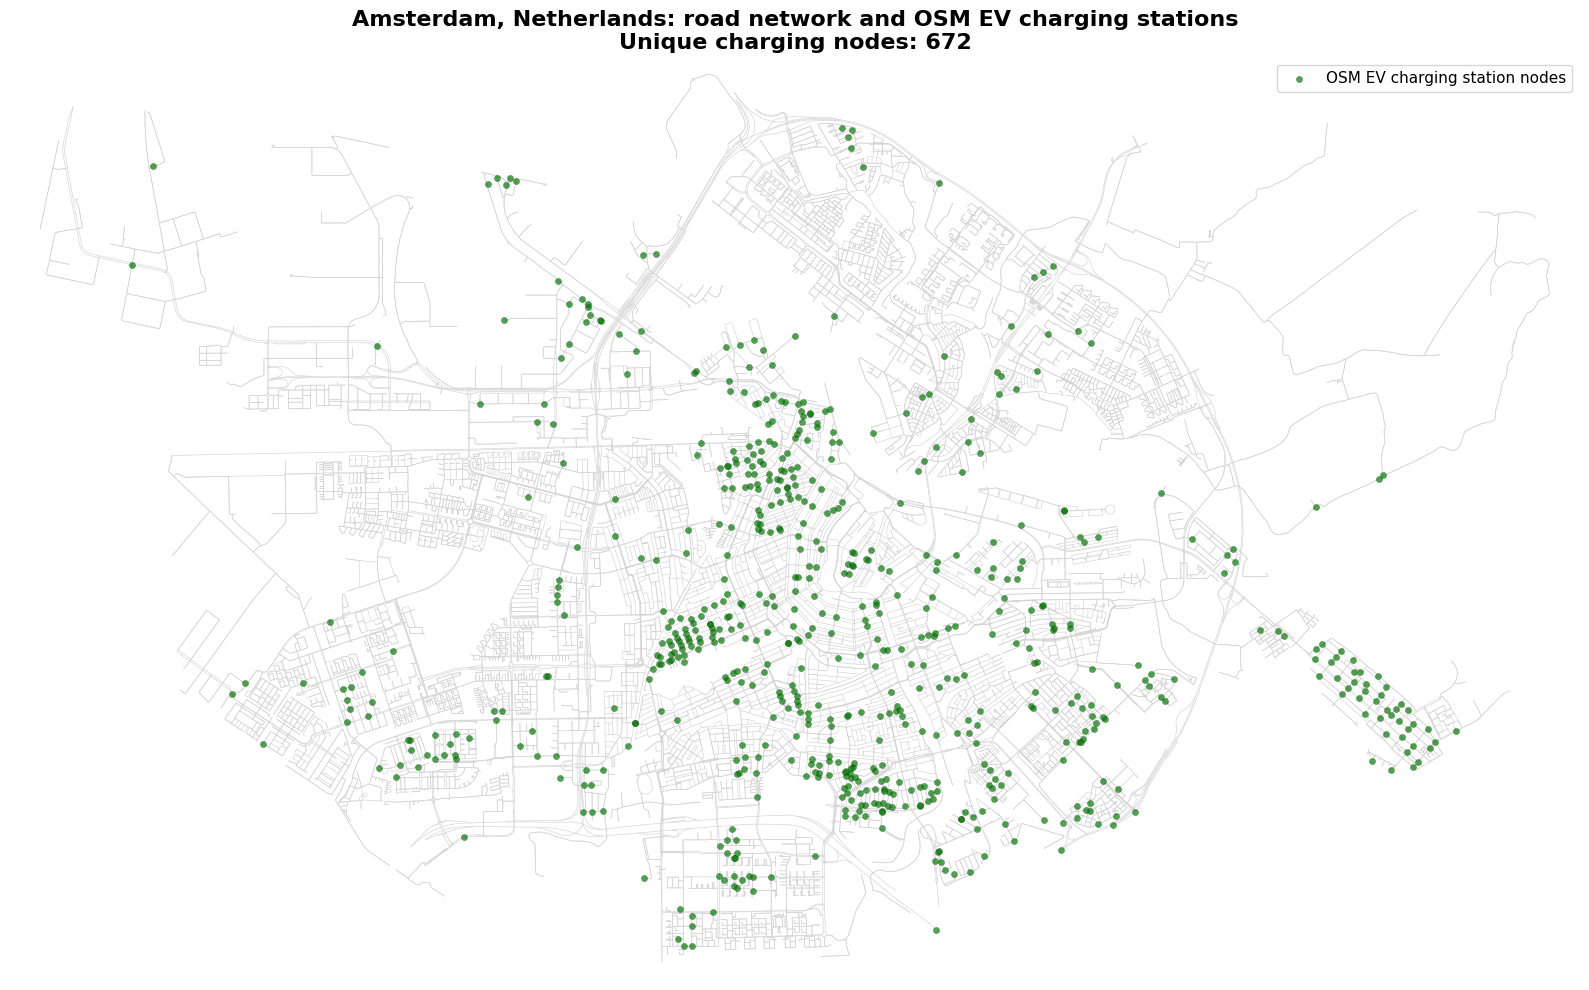

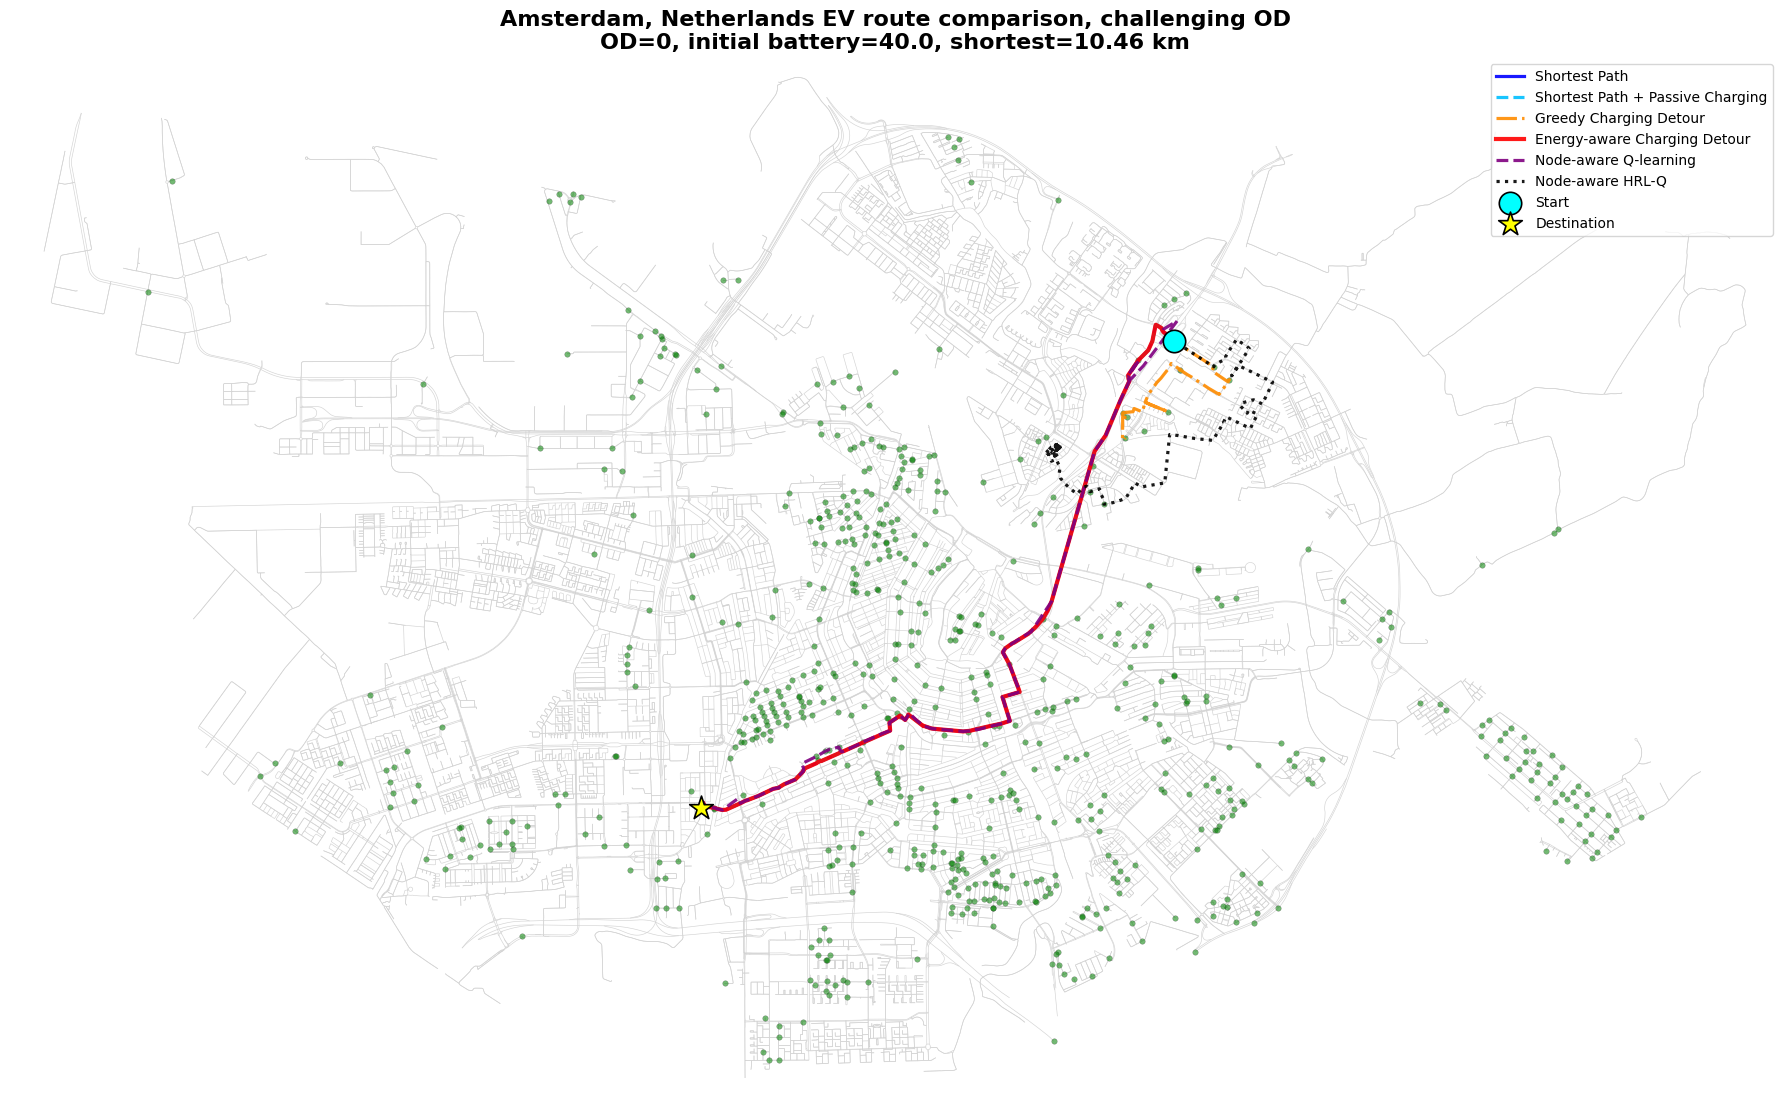

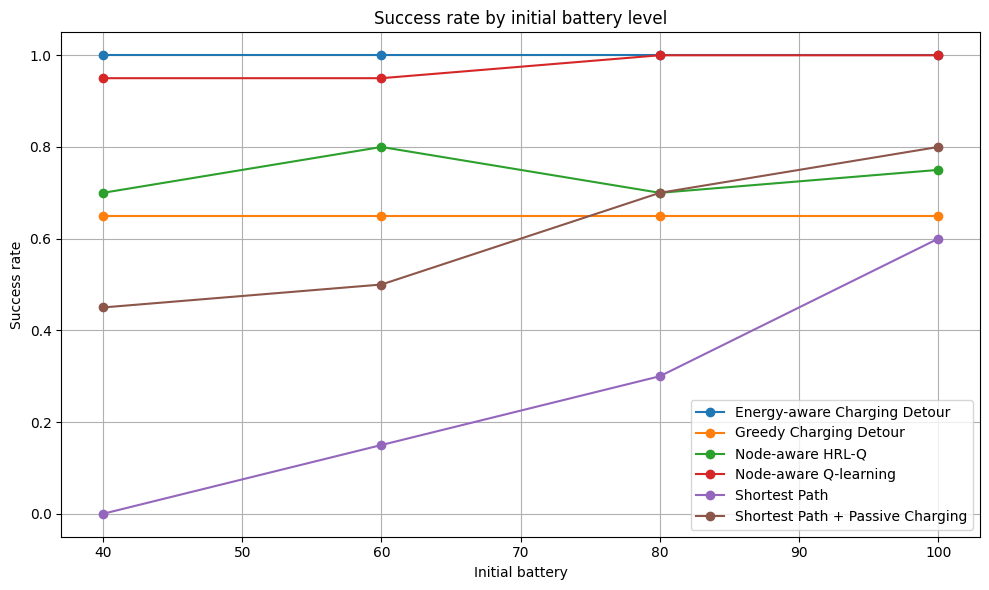

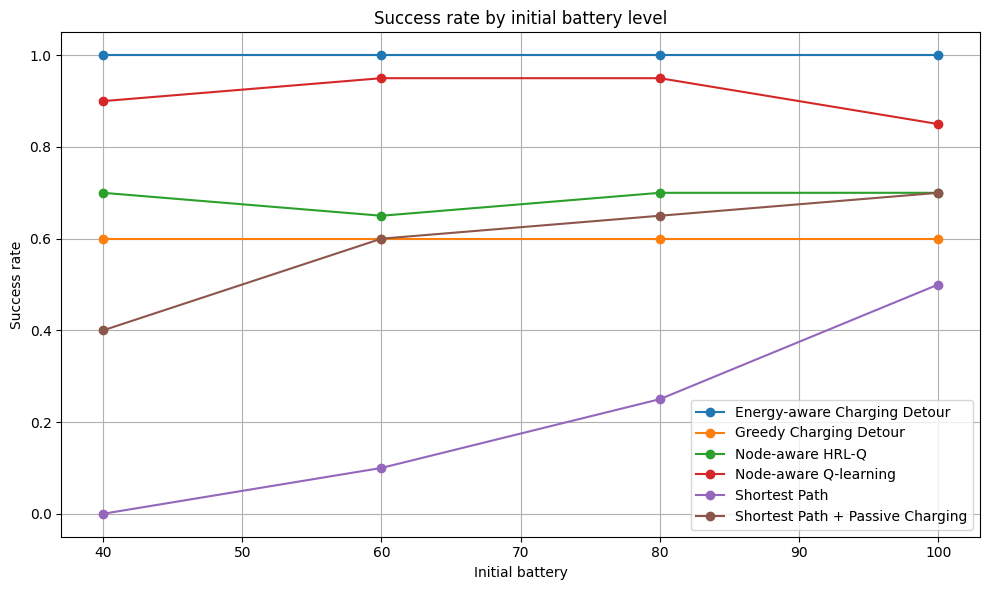

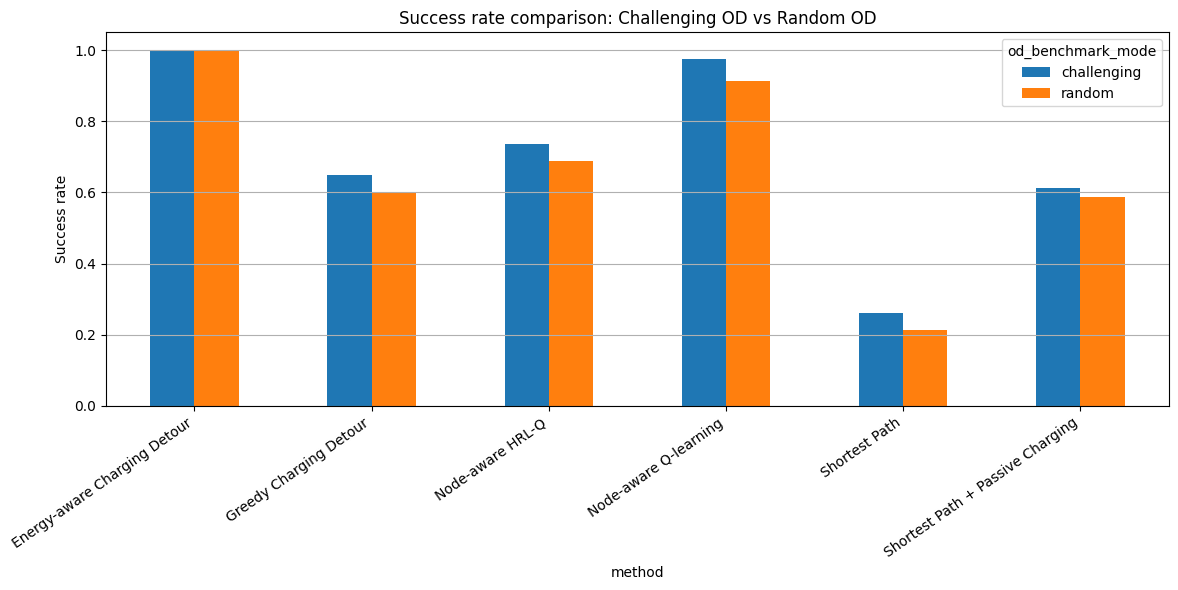

In [ ]:
# ============================================================
# 9) MAIN EXPERIMENT FLOW
# Challenging OD + Random OD under identical parameter settings
# ============================================================

# ------------------------------------------------------------
# Load city and charging infrastructure
# ------------------------------------------------------------
G, stations, station_nodes, city_summary = load_city_graph_and_charging_stations(
    PLACE_NAME, NETWORK_TYPE
)

pd.DataFrame([city_summary]).to_csv(OUTPUT_DIR / "city_charging_summary.csv", index=False)

experiment_config = {
    "place_name": PLACE_NAME,
    "network_type": NETWORK_TYPE,
    "battery_capacity": BATTERY_CAPACITY,
    "energy_per_km": ENERGY_PER_KM,
    "recharge_threshold": RECHARGE_THRESHOLD,
    "safety_margin": SAFETY_MARGIN,
    "energy_model": ENERGY_MODEL,
    "add_speeds_and_travel_times": ADD_SPEEDS_AND_TRAVEL_TIMES,
    "default_speed_kph": DEFAULT_SPEED_KPH,
    "n_od_pairs": N_OD_PAIRS,
    "od_min_km": OD_MIN_KM,
    "od_max_km": OD_MAX_KM,
    "battery_levels": BATTERY_LEVELS,
    "run_rl_single_demo": RUN_RL_SINGLE_DEMO,
    "run_rl_in_benchmark": RUN_RL_IN_BENCHMARK,
    "q_episodes_single": Q_EPISODES_SINGLE,
    "q_episodes_benchmark": Q_EPISODES_BENCHMARK,
    "max_steps_single": MAX_STEPS_SINGLE,
    "max_steps_benchmark": MAX_STEPS_BENCHMARK,
    "od_benchmark_modes": ["challenging", "random"],
    "energy_aware_smart_charging": True,
}
pd.DataFrame([experiment_config]).to_csv(OUTPUT_DIR / "experiment_config.csv", index=False)

plot_city_with_charging_stations(
    G, station_nodes, PLACE_NAME,
    out_path=OUTPUT_DIR / "amsterdam_osm_charging_stations.png",
)

# ------------------------------------------------------------
# Generate OD pairs with identical distance range and count
# ------------------------------------------------------------
print("\nGenerating Challenging OD pairs...")
challenging_od_pairs = find_challenging_od_pairs(
    G=G,
    station_nodes=station_nodes,
    n_pairs=N_OD_PAIRS,
    min_km=OD_MIN_KM,
    max_km=OD_MAX_KM,
    initial_battery=min(BATTERY_LEVELS),
    energy_model=ENERGY_MODEL,
)

if len(challenging_od_pairs) < N_OD_PAIRS:
    print(
        f"Warning: requested {N_OD_PAIRS} challenging OD pairs, "
        f"but found {len(challenging_od_pairs)}. The available challenging subset will be used."
    )

print("\nGenerating Random OD pairs with the same distance range...")
random_od_pairs = generate_random_od_pairs(
    G=G,
    n_pairs=N_OD_PAIRS,
    min_km=OD_MIN_KM,
    max_km=OD_MAX_KM,
)

# Keep names explicit and also preserve od_pairs as challenging set for compatibility
# with the episode sensitivity block below.
od_pairs = challenging_od_pairs

od_sets = {
    "challenging": challenging_od_pairs,
    "random": random_od_pairs,
}

# Save OD pair metadata separately and jointly
od_meta_frames = []
for od_mode, od_list in od_sets.items():
    od_df = pd.DataFrame([
        {
            "od_benchmark_mode": od_mode,
            "od_id": od["od_id"],
            "start": od["start"],
            "end": od["end"],
            "shortest_km": od["shortest_km"],
            "shortest_nodes": od["shortest_nodes"],
            "scenario_type": od.get("scenario_type", ""),
        }
        for od in od_list
    ])
    od_df.to_csv(OUTPUT_DIR / f"selected_od_pairs_{od_mode}.csv", index=False)
    od_meta_frames.append(od_df)
    print(f"\n{od_mode.upper()} OD pairs:")
    print(od_df.head())

if od_meta_frames:
    pd.concat(od_meta_frames, ignore_index=True).to_csv(
        OUTPUT_DIR / "selected_od_pairs_all_modes.csv", index=False
    )

# ------------------------------------------------------------
# Single demonstration on first challenging OD and selected battery
# ------------------------------------------------------------
if len(challenging_od_pairs) > 0:
    print("\nSingle-scenario route comparison, challenging OD...")
    demo_od = challenging_od_pairs[0]
    demo_battery = min(BATTERY_LEVELS)

    classical_records, classical_paths = run_classical_methods_for_od(
        G=G,
        station_nodes=station_nodes,
        od=demo_od,
        initial_battery=demo_battery,
        energy_model=ENERGY_MODEL,
    )

    demo_paths = dict(classical_paths)
    demo_records = list(classical_records)

    if RUN_RL_SINGLE_DEMO:
        rl_records, rl_paths = run_rl_methods_for_od(
            G=G,
            station_nodes=station_nodes,
            od=demo_od,
            initial_battery=demo_battery,
            episodes=Q_EPISODES_SINGLE,
            max_steps=MAX_STEPS_SINGLE,
            energy_model=ENERGY_MODEL,
            verbose=True,
        )
        demo_records.extend(rl_records)
        demo_paths.update(rl_paths)

    demo_df = pd.DataFrame(demo_records)
    demo_df["od_benchmark_mode"] = "challenging_demo"
    demo_df.to_csv(OUTPUT_DIR / "single_scenario_results_challenging.csv", index=False)
    print(demo_df[[
        "method", "energy_model", "success", "failure_reason", "route_length_km",
        "traveled_length_km", "travel_time_min", "shortest_deviation_ratio", "refill_count",
        "energy_used", "min_battery", "final_battery", "loop_count", "smart_charging"
    ]])

    plot_routes(
        G=G,
        station_nodes=station_nodes,
        start_node=demo_od["start"],
        end_node=demo_od["end"],
        route_dict=demo_paths,
        title=(
            f"{PLACE_NAME} EV route comparison, challenging OD\n"
            f"OD={demo_od['od_id']}, initial battery={demo_battery}, "
            f"shortest={demo_od['shortest_km']:.2f} km"
        ),
        out_path=OUTPUT_DIR / "single_scenario_route_comparison_challenging.png",
    )
else:
    print("No challenging OD pair available for single-scenario demonstration.")

# ------------------------------------------------------------
# Benchmark helper: run one OD set under the same global parameters
# ------------------------------------------------------------
def run_benchmark_for_od_set(
    od_mode,
    od_list,
    G,
    station_nodes,
    battery_levels,
    energy_model=ENERGY_MODEL,
):
    print("\n" + "=" * 80)
    print(f"Benchmarking OD mode: {od_mode}")
    print("=" * 80)

    all_records = []
    all_paths = {}
    t_total = time.time()

    for i, od in enumerate(od_list):
        print(f"[{od_mode}] OD {i+1}/{len(od_list)} | shortest={od['shortest_km']:.2f} km")

        for initial_battery in battery_levels:
            records, paths = run_classical_methods_for_od(
                G=G,
                station_nodes=station_nodes,
                od=od,
                initial_battery=initial_battery,
                energy_model=energy_model,
            )

            for r in records:
                r["od_benchmark_mode"] = od_mode
            all_records.extend(records)
            all_paths[(od_mode, od["od_id"], initial_battery)] = paths

            if RUN_RL_IN_BENCHMARK:
                rl_records, rl_paths = run_rl_methods_for_od(
                    G=G,
                    station_nodes=station_nodes,
                    od=od,
                    initial_battery=initial_battery,
                    episodes=Q_EPISODES_BENCHMARK,
                    max_steps=MAX_STEPS_BENCHMARK,
                    energy_model=energy_model,
                    verbose=False,
                )
                for r in rl_records:
                    r["od_benchmark_mode"] = od_mode
                all_records.extend(rl_records)
                all_paths[(od_mode, od["od_id"], initial_battery)].update(rl_paths)

    elapsed = time.time() - t_total
    print(f"Benchmark elapsed for {od_mode}: {elapsed:.2f} s")

    results = pd.DataFrame(all_records)
    results.to_csv(OUTPUT_DIR / f"benchmark_results_{od_mode}.csv", index=False)

    summary = summarize_results(results)
    summary["od_benchmark_mode"] = od_mode
    summary.to_csv(OUTPUT_DIR / f"benchmark_summary_by_method_{od_mode}.csv", index=False)

    summary_battery = summarize_by_battery(results)
    summary_battery["od_benchmark_mode"] = od_mode
    summary_battery.to_csv(OUTPUT_DIR / f"benchmark_summary_by_battery_{od_mode}.csv", index=False)

    print(f"\nSummary by method, {od_mode}:")
    print(summary)

    print(f"\nSummary by battery, {od_mode}:")
    print(summary_battery.head(30))

    plot_success_by_battery(
        summary_battery,
        out_path=OUTPUT_DIR / f"success_rate_by_battery_{od_mode}.png",
    )

    return results, summary, summary_battery, all_paths

# ------------------------------------------------------------
# Run both Challenging OD and Random OD benchmarks with identical parameters
# ------------------------------------------------------------
benchmark_results_by_mode = {}
benchmark_summaries_by_mode = {}
benchmark_battery_summaries_by_mode = {}
all_paths_by_mode = {}

for od_mode, od_list in od_sets.items():
    if len(od_list) == 0:
        print(f"Skipping {od_mode}: no OD pairs available.")
        continue

    results_mode, summary_mode, summary_battery_mode, paths_mode = run_benchmark_for_od_set(
        od_mode=od_mode,
        od_list=od_list,
        G=G,
        station_nodes=station_nodes,
        battery_levels=BATTERY_LEVELS,
        energy_model=ENERGY_MODEL,
    )

    benchmark_results_by_mode[od_mode] = results_mode
    benchmark_summaries_by_mode[od_mode] = summary_mode
    benchmark_battery_summaries_by_mode[od_mode] = summary_battery_mode
    all_paths_by_mode[od_mode] = paths_mode

# ------------------------------------------------------------
# Combined outputs for Challenging vs Random comparison
# ------------------------------------------------------------
if benchmark_results_by_mode:
    results_df = pd.concat(benchmark_results_by_mode.values(), ignore_index=True)
    results_df.to_csv(OUTPUT_DIR / "benchmark_results_all_modes.csv", index=False)

    summary_all_modes = results_df.groupby(["od_benchmark_mode", "method"]).agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        route_length_success_mean=("route_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        travel_time_success_mean=("travel_time_min", "mean"),
        traveled_length_all_mean=("traveled_length_km", "mean"),
        traveled_time_all_mean=("traveled_time_min", "mean"),
        refill_all_mean=("refill_count", "mean"),
        loop_count_all_mean=("loop_count", "mean"),
        computation_time_mean=("computation_time_s", "mean"),
    ).reset_index()
    summary_all_modes.to_csv(OUTPUT_DIR / "benchmark_summary_by_mode_and_method.csv", index=False)

    summary_battery_all_modes = results_df.groupby(["od_benchmark_mode", "initial_battery", "method"]).agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        route_length_success_mean=("route_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        travel_time_success_mean=("travel_time_min", "mean"),
        refill_all_mean=("refill_count", "mean"),
        loop_count_all_mean=("loop_count", "mean"),
    ).reset_index()
    summary_battery_all_modes.to_csv(OUTPUT_DIR / "benchmark_summary_by_mode_battery_method.csv", index=False)

    print("\nCombined Challenging vs Random summary:")
    print(summary_all_modes)

    # Bar-style comparison of method success rates between OD modes
    try:
        pivot_success = summary_all_modes.pivot(
            index="method",
            columns="od_benchmark_mode",
            values="success_rate"
        )
        ax = pivot_success.plot(kind="bar", figsize=(12, 6))
        ax.set_ylabel("Success rate")
        ax.set_title("Success rate comparison: Challenging OD vs Random OD")
        ax.grid(True, axis="y")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "success_rate_challenging_vs_random.png", dpi=300, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("Could not create Challenging vs Random success plot:", e)

print(f"\nOutputs saved to: {OUTPUT_DIR.resolve()}")

,city,od_benchmark_mode,method,n,success_rate,route_length_success_mean,deviation_success_mean,travel_time_success_mean,traveled_length_all_mean,refill_all_mean,loop_count_all_mean,computation_time_mean,multi_city_run_rl
0,"Berlin, Germany",challenging,Energy-aware Charging Detour,80,1.0000,9.952647,1.009836,13.935024,9.952647,2.3375,0.3750,16.555659,True
1,"Berlin, Germany",challenging,Greedy Charging Detour,80,0.5000,7.892289,1.041934,10.984289,5.830513,0.9875,1.6500,57.335681,True
2,"Berlin, Germany",challenging,Node-aware HRL-Q,80,0.9625,14.060097,1.411011,21.572281,14.598367,2.2750,11.7250,16.048847,True
3,"Berlin, Germany",challenging,Node-aware Q-learning,80,1.0000,11.555715,1.168181,16.738715,11.555715,1.6625,1.8250,8.821685,True
4,"Berlin, Germany",challenging,Shortest Path,80,0.1875,6.571938,1.000000,9.479493,6.359847,0.0000,0.0000,0.031273,True
5,"Berlin, Germany",challenging,Shortest Path + Passive Charging,80,0.7500,9.624266,1.000000,13.621968,8.922977,0.8750,0.0000,0.030844,True
6,"Berlin, Germany",random,Energy-aware Charging Detour,80,1.0000,9.564136,1.004912,13.195385,9.564136,2.2000,0.1500,15.412724,True
7,"Berlin, Germany",random,Greedy Charging Detour,80,0.6500,8.509994,1.041326,12.116683,6.648387,1.4125,1.0625,51.864664,True
8,"Berlin, Germany",random,Node-aware HRL-Q,80,0.9250,13.319180,1.423199,20.505451,13.874672,2.1750,23.6000,16.507535,True
9,"Berlin, Germany",random,Node-aware Q-learning,80,0.9875,10.992109,1.158934,15.813587,10.921454,1.5000,1.7625,8.980997,True


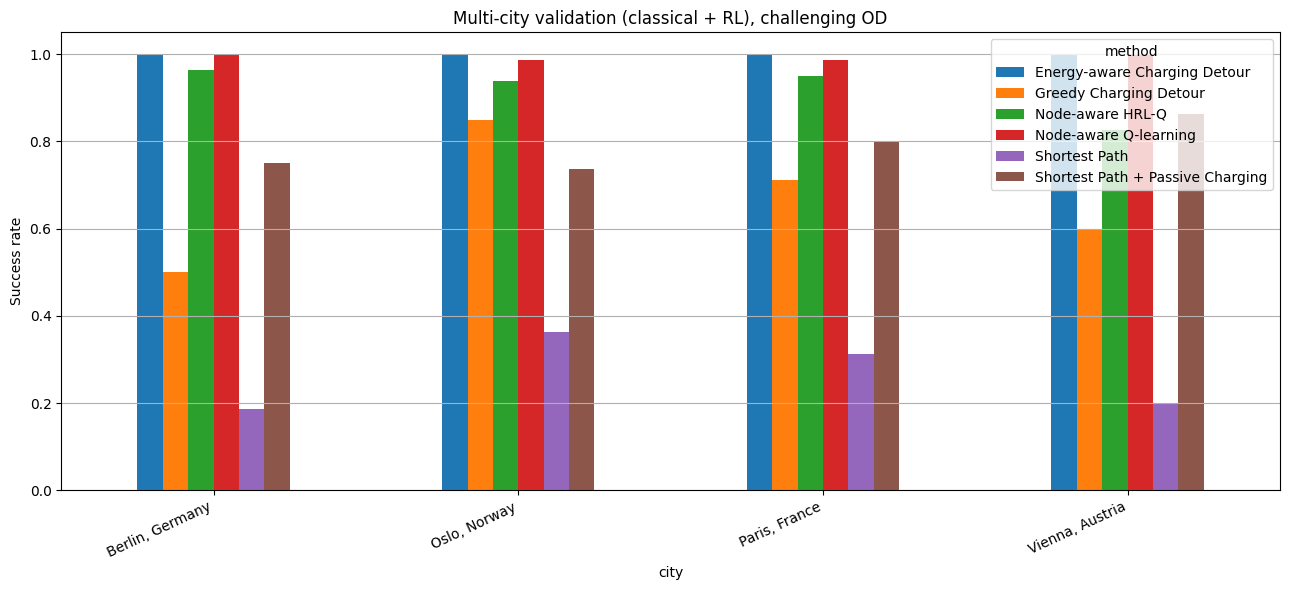

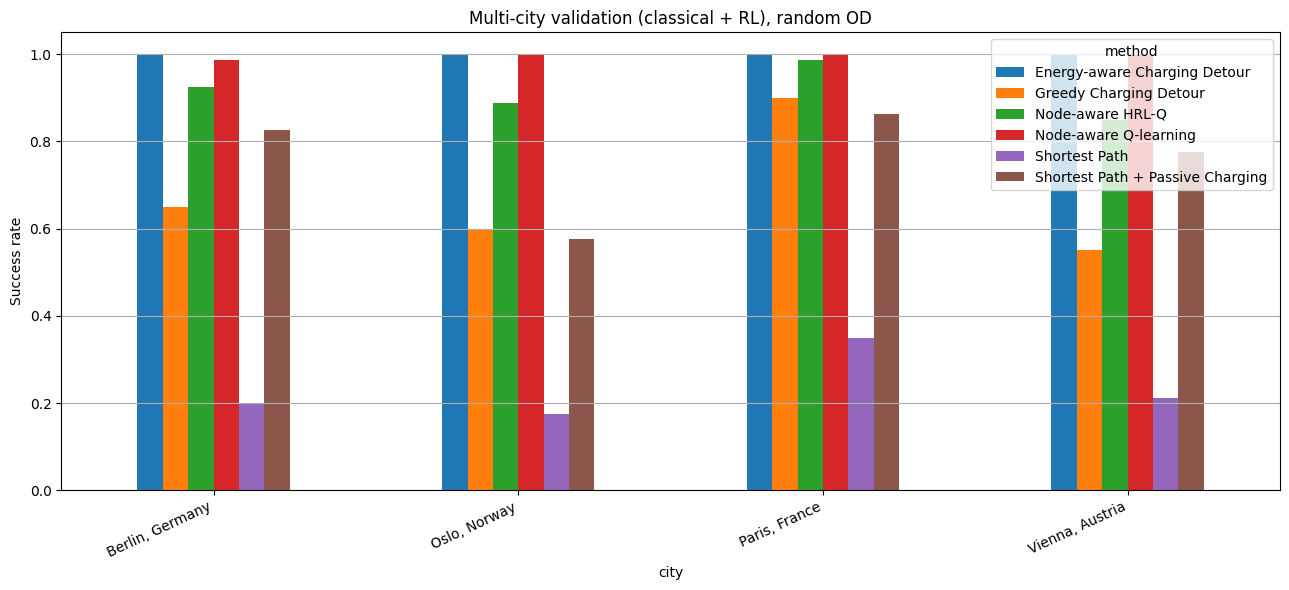

In [ ]:
# ============================================================
# 10) MULTI-CITY VALIDATION
# Classical baselines + optional Q-learning / HRL-Q, no episode sensitivity
# ============================================================

def slugify_place_name(place_name):
    return (
        str(place_name)
        .lower()
        .replace(",", "")
        .replace(" ", "_")
        .replace("/", "_")
    )


def run_multicity_benchmark_for_od_set(
    od_mode,
    od_list,
    G_city,
    station_nodes_city,
    battery_levels,
    city_name,
    energy_model=ENERGY_MODEL,
    output_dir=OUTPUT_DIR,
    run_rl=MULTI_CITY_RUN_RL,
    rl_episodes=Q_EPISODES_BENCHMARK,
    rl_max_steps=MAX_STEPS_BENCHMARK,
):
    """
    Run multi-city benchmark for one city and one OD mode.

    Always evaluates classical baselines:
    - Shortest Path
    - Shortest Path + Passive Charging
    - Greedy Charging Detour
    - Energy-aware Charging Detour

    If run_rl=True, also evaluates:
    - Node-aware Q-learning
    - Node-aware HRL-Q

    Episode sensitivity is intentionally not run here.
    """
    print("\n" + "=" * 80)
    method_scope = "classical + RL" if run_rl else "classical only"
    print(f"Multi-city benchmark ({method_scope}) | city={city_name} | OD mode={od_mode}")
    print("=" * 80)

    all_records = []
    t_total = time.time()

    for i, od in enumerate(od_list):
        print(f"[{city_name} | {od_mode}] OD {i+1}/{len(od_list)} | shortest={od['shortest_km']:.2f} km")

        for initial_battery in battery_levels:
            records, _ = run_classical_methods_for_od(
                G=G_city,
                station_nodes=station_nodes_city,
                od=od,
                initial_battery=initial_battery,
                energy_model=energy_model,
            )

            for r in records:
                r["city"] = city_name
                r["od_benchmark_mode"] = od_mode
                r["benchmark_scope"] = method_scope
            all_records.extend(records)

            if run_rl:
                rl_records, _ = run_rl_methods_for_od(
                    G=G_city,
                    station_nodes=station_nodes_city,
                    od=od,
                    initial_battery=initial_battery,
                    episodes=rl_episodes,
                    max_steps=rl_max_steps,
                    energy_model=energy_model,
                    verbose=False,
                )

                for r in rl_records:
                    r["city"] = city_name
                    r["od_benchmark_mode"] = od_mode
                    r["benchmark_scope"] = method_scope
                all_records.extend(rl_records)

    elapsed = time.time() - t_total
    print(
        f"Multi-city benchmark elapsed | city={city_name} | mode={od_mode} | "
        f"run_rl={run_rl}: {elapsed:.2f} s"
    )

    results = pd.DataFrame(all_records)
    return results


def run_multi_city_validation(
    places,
    n_od_pairs=20,
    min_km=5,
    max_km=15,
    battery_levels=None,
    energy_model=ENERGY_MODEL,
    output_dir=OUTPUT_DIR,
    run_rl=MULTI_CITY_RUN_RL,
    rl_episodes=Q_EPISODES_BENCHMARK,
    rl_max_steps=MAX_STEPS_BENCHMARK,
):
    """
    Run validation across multiple cities.

    For each city, the code:
    1. Loads the OSM drivable road network.
    2. Extracts amenity=charging_station points.
    3. Generates Challenging OD and/or Random OD sets using the same global parameters.
    4. Evaluates classical baselines.
    5. If run_rl=True, also evaluates Node-aware Q-learning and Node-aware HRL-Q.

    Episode sensitivity is intentionally skipped in this block.
    """
    if battery_levels is None:
        battery_levels = BATTERY_LEVELS

    city_summaries = []
    all_city_results = []
    all_city_od_meta = []

    for place_name in places:
        city_slug = slugify_place_name(place_name)
        city_dir = output_dir / "multi_city" / city_slug
        city_dir.mkdir(parents=True, exist_ok=True)

        print("\n" + "#" * 100)
        print(f"MULTI-CITY VALIDATION: {place_name}")
        print("#" * 100)

        try:
            G_city, stations_city, station_nodes_city, city_summary = load_city_graph_and_charging_stations(
                place_name, NETWORK_TYPE
            )
        except Exception as e:
            print(f"Skipping {place_name} due to loading error: {e}")
            city_summaries.append({
                "city": place_name,
                "status": "load_error",
                "error": str(e),
                "multi_city_run_rl": run_rl,
            })
            continue

        city_summary["status"] = "ok"
        city_summary["validation_type"] = "multi_city_classical_plus_rl" if run_rl else "multi_city_classical_only"
        city_summary["multi_city_run_rl"] = run_rl
        city_summary["q_episodes_benchmark"] = rl_episodes if run_rl else 0
        city_summary["max_steps_benchmark"] = rl_max_steps if run_rl else 0
        city_summaries.append(city_summary)

        pd.DataFrame([city_summary]).to_csv(city_dir / "city_charging_summary.csv", index=False)

        od_sets_city = {}

        if MULTI_CITY_INCLUDE_CHALLENGING:
            print(f"\nGenerating challenging OD pairs for {place_name}...")
            challenging_city = find_challenging_od_pairs(
                G=G_city,
                station_nodes=station_nodes_city,
                n_pairs=n_od_pairs,
                min_km=min_km,
                max_km=max_km,
                initial_battery=min(battery_levels),
                energy_model=energy_model,
            )
            od_sets_city["challenging"] = challenging_city

        if MULTI_CITY_INCLUDE_RANDOM:
            print(f"\nGenerating random OD pairs for {place_name}...")
            random_city = generate_random_od_pairs(
                G=G_city,
                n_pairs=n_od_pairs,
                min_km=min_km,
                max_km=max_km,
            )
            od_sets_city["random"] = random_city

        for od_mode, od_list in od_sets_city.items():
            if len(od_list) == 0:
                print(f"Skipping {place_name} | {od_mode}: no OD pairs available.")
                continue

            od_meta = pd.DataFrame([
                {
                    "city": place_name,
                    "od_benchmark_mode": od_mode,
                    "od_id": od["od_id"],
                    "start": od["start"],
                    "end": od["end"],
                    "shortest_km": od["shortest_km"],
                    "shortest_nodes": od["shortest_nodes"],
                    "scenario_type": od.get("scenario_type", ""),
                    "multi_city_run_rl": run_rl,
                }
                for od in od_list
            ])
            od_meta.to_csv(city_dir / f"selected_od_pairs_{od_mode}.csv", index=False)
            all_city_od_meta.append(od_meta)

            results_city_mode = run_multicity_benchmark_for_od_set(
                od_mode=od_mode,
                od_list=od_list,
                G_city=G_city,
                station_nodes_city=station_nodes_city,
                battery_levels=battery_levels,
                city_name=place_name,
                energy_model=energy_model,
                output_dir=city_dir,
                run_rl=run_rl,
                rl_episodes=rl_episodes,
                rl_max_steps=rl_max_steps,
            )

            results_city_mode.to_csv(city_dir / f"benchmark_results_{od_mode}.csv", index=False)
            all_city_results.append(results_city_mode)

            summary_city_mode = summarize_results(results_city_mode)
            summary_city_mode["city"] = place_name
            summary_city_mode["od_benchmark_mode"] = od_mode
            summary_city_mode["multi_city_run_rl"] = run_rl
            summary_city_mode.to_csv(city_dir / f"benchmark_summary_by_method_{od_mode}.csv", index=False)

            summary_battery_city_mode = summarize_by_battery(results_city_mode)
            summary_battery_city_mode["city"] = place_name
            summary_battery_city_mode["od_benchmark_mode"] = od_mode
            summary_battery_city_mode["multi_city_run_rl"] = run_rl
            summary_battery_city_mode.to_csv(city_dir / f"benchmark_summary_by_battery_{od_mode}.csv", index=False)

    # Combined multi-city outputs
    city_summary_df = pd.DataFrame(city_summaries)
    city_summary_df.to_csv(output_dir / "multicity_city_summary.csv", index=False)

    if all_city_od_meta:
        multicity_od_meta = pd.concat(all_city_od_meta, ignore_index=True)
        multicity_od_meta.to_csv(output_dir / "multicity_selected_od_pairs_all.csv", index=False)

    if not all_city_results:
        print("No multi-city benchmark results were produced.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), city_summary_df

    multicity_results = pd.concat(all_city_results, ignore_index=True)
    multicity_results.to_csv(output_dir / "multicity_benchmark_results_all.csv", index=False)

    multicity_summary = multicity_results.groupby(["city", "od_benchmark_mode", "method"]).agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        route_length_success_mean=("route_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        travel_time_success_mean=("travel_time_min", "mean"),
        traveled_length_all_mean=("traveled_length_km", "mean"),
        refill_all_mean=("refill_count", "mean"),
        loop_count_all_mean=("loop_count", "mean"),
        computation_time_mean=("computation_time_s", "mean"),
    ).reset_index()
    multicity_summary["multi_city_run_rl"] = run_rl
    multicity_summary.to_csv(output_dir / "multicity_summary_by_city_mode_method.csv", index=False)

    multicity_battery_summary = multicity_results.groupby(["city", "od_benchmark_mode", "initial_battery", "method"]).agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        route_length_success_mean=("route_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        travel_time_success_mean=("travel_time_min", "mean"),
        refill_all_mean=("refill_count", "mean"),
        loop_count_all_mean=("loop_count", "mean"),
    ).reset_index()
    multicity_battery_summary["multi_city_run_rl"] = run_rl
    multicity_battery_summary.to_csv(output_dir / "multicity_summary_by_city_mode_battery_method.csv", index=False)

    print("\nMulti-city summary by city, OD mode, and method:")
    display(multicity_summary)

    # Compact plot: success rate by city/method for each OD mode.
    try:
        for od_mode in multicity_summary["od_benchmark_mode"].unique():
            temp = multicity_summary[multicity_summary["od_benchmark_mode"] == od_mode]
            pivot = temp.pivot(index="city", columns="method", values="success_rate")
            ax = pivot.plot(kind="bar", figsize=(13, 6))
            ax.set_ylabel("Success rate")
            scope_title = "classical + RL" if run_rl else "classical only"
            ax.set_title(f"Multi-city validation ({scope_title}), {od_mode} OD")
            ax.grid(True, axis="y")
            plt.xticks(rotation=25, ha="right")
            plt.tight_layout()
            plt.savefig(output_dir / f"multicity_success_rate_by_city_{od_mode}.png", dpi=300, bbox_inches="tight")
            plt.show()
    except Exception as e:
        print("Could not create multi-city success plots:", e)

    return multicity_results, multicity_summary, multicity_battery_summary, city_summary_df


if RUN_MULTI_CITY_VALIDATION:
    print("\n" + "=" * 100)
    print("RUNNING MULTI-CITY VALIDATION")
    print("=" * 100)
    print(f"Cities: {MULTI_CITY_PLACES}")
    print(f"N_OD_PAIRS per city/mode: {MULTI_CITY_N_OD_PAIRS}")
    print(f"OD distance range: {OD_MIN_KM}-{OD_MAX_KM} km")
    print(f"Battery levels: {MULTI_CITY_BATTERY_LEVELS}")
    print(f"Energy model: {ENERGY_MODEL}")
    print(f"MULTI_CITY_RUN_RL: {MULTI_CITY_RUN_RL}")
    if MULTI_CITY_RUN_RL:
        print(f"Multi-city RL methods are enabled: Node-aware Q-learning and Node-aware HRL-Q.")
        print(f"Q_EPISODES_BENCHMARK: {Q_EPISODES_BENCHMARK}")
        print(f"MAX_STEPS_BENCHMARK: {MAX_STEPS_BENCHMARK}")
        print("Episode sensitivity is still not run in this multi-city block.")
    else:
        print("Multi-city validation runs classical baselines only.")
        print("Episode sensitivity is not run in this multi-city block.")

    multicity_results_df, multicity_summary_df, multicity_battery_summary_df, multicity_city_summary_df = run_multi_city_validation(
        places=MULTI_CITY_PLACES,
        n_od_pairs=MULTI_CITY_N_OD_PAIRS,
        min_km=OD_MIN_KM,
        max_km=OD_MAX_KM,
        battery_levels=MULTI_CITY_BATTERY_LEVELS,
        energy_model=ENERGY_MODEL,
        output_dir=OUTPUT_DIR,
        run_rl=MULTI_CITY_RUN_RL,
        rl_episodes=Q_EPISODES_BENCHMARK,
        rl_max_steps=MAX_STEPS_BENCHMARK,
    )
else:
    print("Multi-city validation is disabled. Set RUN_MULTI_CITY_VALIDATION = True to run it.")

In [ ]:
# ============================================================
# 10) EPISODE SENSITIVITY ANALYSIS
# Q-learning + HRL-Q combined version
# ============================================================

RUN_EPISODE_SENSITIVITY = False

# Full paper-oriented list.
# For quick test, temporarily use [500, 1000, 2000].
EPISODE_LIST = [500, 1000, 2000, 5000, 10000, 20000]

# Keep these identical for Q-learning and HRL-Q
SENSITIVITY_N_OD_PAIRS = 20
SENSITIVITY_BATTERY_LEVELS = [40.0, 60.0, 80.0, 100.0]
SENSITIVITY_MAX_STEPS = 300
SENSITIVITY_REPEATS = 1

# Run both methods under exactly the same scenario set
SENSITIVITY_METHODS = [
    {
        "method_name": "Node-aware Q-learning",
        "use_hrl": False
    },
    {
        "method_name": "Node-aware HRL-Q",
        "use_hrl": True
    }
]


def run_episode_sensitivity_analysis_both_methods(
    G,
    station_nodes,
    od_pairs,
    episode_list,
    battery_levels,
    methods,
    max_steps=300,
    n_od_pairs=10,
    repeats=1,
    energy_model=ENERGY_MODEL,
    output_dir=OUTPUT_DIR,
    base_seed=RANDOM_SEED,
):
    """
    Run episode sensitivity analysis for both Node-aware Q-learning and Node-aware HRL-Q.

    The same OD-pair subset, battery levels, episode counts, max step value,
    energy model, and random seed logic are used for both methods.

    Outputs:
    - episode_sensitivity_results_both_methods.csv
    - episode_sensitivity_summary_both_methods.csv
    - comparison plots for Q-learning vs HRL-Q
    """

    selected_ods = list(od_pairs[:n_od_pairs])

    if len(selected_ods) == 0:
        raise ValueError("No OD pairs available for episode sensitivity analysis.")

    sensitivity_records = []

    total_runs = (
        len(methods)
        * len(episode_list)
        * len(selected_ods)
        * len(battery_levels)
        * repeats
    )

    run_counter = 0

    print("\n" + "=" * 80)
    print("EPISODE SENSITIVITY ANALYSIS, Q-learning + HRL-Q")
    print("=" * 80)
    print(f"Methods: {[m['method_name'] for m in methods]}")
    print(f"Episode list: {episode_list}")
    print(f"OD pairs: {len(selected_ods)}")
    print(f"Battery levels: {battery_levels}")
    print(f"Repeats: {repeats}")
    print(f"Max steps: {max_steps}")
    print(f"Energy model: {energy_model}")
    print(f"Total training/evaluation runs: {total_runs}")

    for method_cfg in methods:
        method_name = method_cfg["method_name"]
        use_hrl = method_cfg["use_hrl"]

        print("\n" + "#" * 80)
        print(f"METHOD: {method_name}")
        print("#" * 80)

        for ep_count in episode_list:
            print("\n" + "-" * 70)
            print(f"Method: {method_name} | Episode count: {ep_count}")
            print("-" * 70)

            for repeat_idx in range(repeats):
                # Same seed logic for fairer comparison.
                # The method offset prevents Q and HRL from producing identical stochastic paths.
                method_offset = 100000 if use_hrl else 0
                run_seed = base_seed + repeat_idx + ep_count + method_offset

                random.seed(run_seed)
                np.random.seed(run_seed)

                for od in selected_ods:
                    for initial_battery in battery_levels:
                        run_counter += 1

                        print(
                            f"[{run_counter}/{total_runs}] "
                            f"method={method_name} | "
                            f"ep={ep_count} | repeat={repeat_idx} | "
                            f"OD={od['od_id']} | battery={initial_battery}"
                        )

                        t0 = time.time()

                        env_train = NodeAwareEVEnvironment(
                            G,
                            od["start"],
                            od["end"],
                            station_nodes,
                            battery_capacity=BATTERY_CAPACITY,
                            initial_battery=initial_battery,
                            energy_per_km=ENERGY_PER_KM,
                            recharge_threshold=RECHARGE_THRESHOLD,
                            max_steps=max_steps,
                            energy_model=energy_model,
                        )

                        agent, best_path, best_metrics, train_history = train_node_aware_q(
                            env_train,
                            episodes=ep_count,
                            use_hrl=use_hrl,
                            verbose=False,
                        )

                        train_elapsed = time.time() - t0

                        env_eval = NodeAwareEVEnvironment(
                            G,
                            od["start"],
                            od["end"],
                            station_nodes,
                            battery_capacity=BATTERY_CAPACITY,
                            initial_battery=initial_battery,
                            energy_per_km=ENERGY_PER_KM,
                            recharge_threshold=RECHARGE_THRESHOLD,
                            max_steps=max_steps,
                            energy_model=energy_model,
                        )

                        eval_path, eval_metrics = evaluate_node_aware_q(
                            env_eval,
                            agent,
                            use_hrl=use_hrl,
                        )

                        total_elapsed = time.time() - t0

                        # Training history summary
                        hist_success_last_50 = np.nan
                        hist_reward_last_50 = np.nan
                        hist_loop_last_50 = np.nan

                        if train_history is not None and len(train_history) > 0:
                            tail = train_history.tail(min(50, len(train_history)))
                            hist_success_last_50 = tail["success"].mean()
                            hist_reward_last_50 = tail["total_reward"].mean()
                            hist_loop_last_50 = tail["loop_count"].mean()

                        record = dict(eval_metrics)

                        record.update({
                            "episode_count": ep_count,
                            "repeat": repeat_idx,
                            "od_id": od["od_id"],
                            "start": od["start"],
                            "end": od["end"],
                            "initial_battery": initial_battery,
                            "shortest_km": od.get("shortest_km", np.nan),
                            "scenario_type": od.get("scenario_type", ""),
                            "energy_model": energy_model,
                            "sensitivity_method": method_name,
                            "use_hrl": use_hrl,
                            "training_time_s": train_elapsed,
                            "total_time_s": total_elapsed,
                            "train_success_last_50_mean": hist_success_last_50,
                            "train_reward_last_50_mean": hist_reward_last_50,
                            "train_loop_last_50_mean": hist_loop_last_50,
                            "q_table_state_count": len(agent.q),
                            "q_table_action_count": sum(len(v) for v in agent.q.values()),
                        })

                        sensitivity_records.append(record)

    sensitivity_df = pd.DataFrame(sensitivity_records)

    results_path = output_dir / "episode_sensitivity_results_both_methods.csv"
    sensitivity_df.to_csv(results_path, index=False)

    # Summary
    summary = sensitivity_df.groupby(
        ["episode_count", "sensitivity_method"]
    ).agg(
        n=("success", "count"),
        success_rate=("success", "mean"),
        route_length_success_mean=("route_length_km", "mean"),
        deviation_success_mean=("shortest_deviation_ratio", "mean"),
        travel_time_success_mean=("travel_time_min", "mean"),
        loop_count_all_mean=("loop_count", "mean"),
        training_time_mean=("training_time_s", "mean"),
        total_time_mean=("total_time_s", "mean"),
        q_table_state_count_mean=("q_table_state_count", "mean"),
        q_table_action_count_mean=("q_table_action_count", "mean"),
        train_success_last_50_mean=("train_success_last_50_mean", "mean"),
        train_reward_last_50_mean=("train_reward_last_50_mean", "mean"),
        train_loop_last_50_mean=("train_loop_last_50_mean", "mean"),
    ).reset_index()

    # Refill count only for successful routes
    refill_success = (
        sensitivity_df[sensitivity_df["success"] == 1]
        .groupby(["episode_count", "sensitivity_method"])["refill_count"]
        .mean()
        .reset_index()
        .rename(columns={"refill_count": "refill_success_mean"})
    )

    summary = summary.merge(
        refill_success,
        on=["episode_count", "sensitivity_method"],
        how="left"
    )

    summary_path = output_dir / "episode_sensitivity_summary_both_methods.csv"
    summary.to_csv(summary_path, index=False)

    print("\nEpisode sensitivity summary, both methods:")
    display(summary)

    print("\nSaved files:")
    print("-", results_path)
    print("-", summary_path)

    return sensitivity_df, summary


def plot_episode_sensitivity_summary_both_methods(
    summary_df,
    output_dir=OUTPUT_DIR
):
    """
    Create comparison plots for Q-learning vs HRL-Q episode sensitivity.
    """

    if summary_df is None or len(summary_df) == 0:
        print("No sensitivity summary to plot.")
        return

    plot_specs = [
        (
            "success_rate",
            "Success rate",
            "episode_sensitivity_both_success_rate.png"
        ),
        (
            "deviation_success_mean",
            "Mean route deviation, successful routes",
            "episode_sensitivity_both_deviation.png"
        ),
        (
            "travel_time_success_mean",
            "Mean travel time, successful routes (min)",
            "episode_sensitivity_both_travel_time.png"
        ),
        (
            "loop_count_all_mean",
            "Mean loop count, all routes",
            "episode_sensitivity_both_loop_count.png"
        ),
        (
            "training_time_mean",
            "Mean training time (s)",
            "episode_sensitivity_both_training_time.png"
        ),
        (
            "train_success_last_50_mean",
            "Training success, last 50 episodes",
            "episode_sensitivity_both_train_success_last50.png"
        ),
        (
            "q_table_state_count_mean",
            "Mean Q-table state count",
            "episode_sensitivity_both_qtable_states.png"
        ),
        (
            "q_table_action_count_mean",
            "Mean Q-table action count",
            "episode_sensitivity_both_qtable_actions.png"
        ),
    ]

    for y_col, y_label, fname in plot_specs:
        if y_col not in summary_df.columns:
            continue

        plt.figure(figsize=(9, 5))

        for method in summary_df["sensitivity_method"].unique():
            temp = summary_df[
                summary_df["sensitivity_method"] == method
            ].sort_values("episode_count")

            plt.plot(
                temp["episode_count"],
                temp[y_col],
                marker="o",
                linewidth=2,
                label=method
            )

        plt.xlabel("Training episodes")
        plt.ylabel(y_label)
        plt.title(y_label + " vs training episode count")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        save_path = output_dir / fname
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", save_path)


def create_episode_sensitivity_paper_table(summary_df):
    """
    Create a compact paper-friendly table.
    """

    if summary_df is None or len(summary_df) == 0:
        return pd.DataFrame()

    cols = [
        "episode_count",
        "sensitivity_method",
        "success_rate",
        "deviation_success_mean",
        "travel_time_success_mean",
        "loop_count_all_mean",
        "training_time_mean",
        "train_success_last_50_mean",
        "q_table_state_count_mean",
        "q_table_action_count_mean",
    ]

    existing_cols = [c for c in cols if c in summary_df.columns]

    paper_table = summary_df[existing_cols].copy()

    rename_map = {
        "episode_count": "Episodes",
        "sensitivity_method": "Method",
        "success_rate": "Success Rate",
        "deviation_success_mean": "Route Deviation",
        "travel_time_success_mean": "Travel Time (min)",
        "loop_count_all_mean": "Loop Count",
        "training_time_mean": "Training Time (s)",
        "train_success_last_50_mean": "Train Success Last-50",
        "q_table_state_count_mean": "Q-table States",
        "q_table_action_count_mean": "Q-table Actions",
    }

    paper_table = paper_table.rename(columns=rename_map)

    # Round numeric columns
    numeric_cols = paper_table.select_dtypes(include=[np.number]).columns
    paper_table[numeric_cols] = paper_table[numeric_cols].round(4)

    return paper_table


if RUN_EPISODE_SENSITIVITY:
    sensitivity_df, sensitivity_summary = run_episode_sensitivity_analysis_both_methods(
        G=G,
        station_nodes=station_nodes,
        od_pairs=od_pairs,
        episode_list=EPISODE_LIST,
        battery_levels=SENSITIVITY_BATTERY_LEVELS,
        methods=SENSITIVITY_METHODS,
        max_steps=SENSITIVITY_MAX_STEPS,
        n_od_pairs=SENSITIVITY_N_OD_PAIRS,
        repeats=SENSITIVITY_REPEATS,
        energy_model=ENERGY_MODEL,
        output_dir=OUTPUT_DIR,
    )

    plot_episode_sensitivity_summary_both_methods(
        sensitivity_summary,
        output_dir=OUTPUT_DIR
    )

    sensitivity_paper_table = create_episode_sensitivity_paper_table(
        sensitivity_summary
    )

    paper_table_path = OUTPUT_DIR / "episode_sensitivity_paper_table_both_methods.csv"
    sensitivity_paper_table.to_csv(paper_table_path, index=False)

    print("\nPaper-friendly episode sensitivity table:")
    display(sensitivity_paper_table)

    print("\nEpisode sensitivity files saved:")
    print("-", OUTPUT_DIR / "episode_sensitivity_results_both_methods.csv")
    print("-", OUTPUT_DIR / "episode_sensitivity_summary_both_methods.csv")
    print("-", paper_table_path)

else:
    print("Episode sensitivity analysis is disabled. Set RUN_EPISODE_SENSITIVITY = True to run it.")

In [ ]:

# ============================================================
# FINAL OUTPUT CONSOLIDATION
# ============================================================
# Run this cell after all experiments finish.
# It collects CSV outputs into one Excel workbook and writes a compact run summary.

import re

def _safe_sheet_name(name, used_names):
    """Create an Excel-compatible unique sheet name."""
    name = re.sub(r"[\[\]\:\*\?\/\\]", "_", str(name))
    name = name.replace(".csv", "")
    name = name[-31:] if len(name) > 31 else name
    base = name[:31] if name else "sheet"
    candidate = base
    counter = 1
    while candidate in used_names:
        suffix = f"_{counter}"
        candidate = (base[:31-len(suffix)] + suffix)
        counter += 1
    used_names.add(candidate)
    return candidate

def consolidate_csv_outputs_to_excel(output_dir=OUTPUT_DIR, workbook_name="all_results.xlsx"):
    """Merge all CSV outputs in OUTPUT_DIR into a single Excel workbook."""
    output_dir = Path(output_dir)
    csv_files = sorted(output_dir.rglob("*.csv"))
    workbook_path = output_dir / workbook_name

    if not csv_files:
        print("No CSV files found to consolidate.")
        return None

    try:
        import openpyxl  # noqa: F401
    except Exception:
        print("openpyxl not found; installing it for Excel export...")
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openpyxl"], check=False)

    used_names = set()
    with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
        index_rows = []
        for csv_path in csv_files:
            rel_name = str(csv_path.relative_to(output_dir))
            sheet_name = _safe_sheet_name(rel_name, used_names)
            try:
                df = pd.read_csv(csv_path)
                if len(df) > 1_048_000:
                    # Excel row limit safety.
                    df.head(1_048_000).to_excel(writer, sheet_name=sheet_name, index=False)
                    note = "truncated_to_excel_row_limit"
                else:
                    df.to_excel(writer, sheet_name=sheet_name, index=False)
                    note = "ok"
                index_rows.append({
                    "sheet_name": sheet_name,
                    "source_csv": rel_name,
                    "rows": len(df),
                    "columns": len(df.columns),
                    "note": note
                })
            except Exception as e:
                index_rows.append({
                    "sheet_name": sheet_name,
                    "source_csv": rel_name,
                    "rows": None,
                    "columns": None,
                    "note": f"failed: {e}"
                })

        pd.DataFrame(index_rows).to_excel(writer, sheet_name="INDEX", index=False)

    register_output_file(workbook_path, "Consolidated Excel workbook containing all CSV outputs")
    print("Consolidated Excel workbook saved to:", workbook_path)
    return workbook_path

def write_final_run_summary(output_dir=OUTPUT_DIR):
    """Write a final human-readable summary of generated outputs."""
    output_dir = Path(output_dir)
    all_files = sorted([p for p in output_dir.rglob("*") if p.is_file()])
    summary_lines = []
    summary_lines.append("ChargeStationMakale run summary")
    summary_lines.append("=" * 80)
    summary_lines.append(f"Notebook run name: {NOTEBOOK_RUN_NAME}")
    summary_lines.append(f"Run timestamp: {RUN_TIMESTAMP}")
    summary_lines.append(f"Google Drive mounted: {DRIVE_MOUNTED}")
    summary_lines.append(f"Output directory: {OUTPUT_DIR}")
    summary_lines.append("")
    summary_lines.append("Generated files:")
    for p in all_files:
        try:
            size_kb = p.stat().st_size / 1024
            summary_lines.append(f"- {p.relative_to(output_dir)} | {size_kb:.1f} KB")
        except Exception:
            summary_lines.append(f"- {p}")
    summary_text = "\n".join(summary_lines)
    path = save_text(summary_text, "final_run_summary.txt")
    print(summary_text)
    print("\nFinal run summary saved to:", path)
    return path

# Save a few common final DataFrame variables again with stable names if they exist.
_COMMON_RESULT_VARIABLES = [
    "city_summary_df",
    "multicity_results",
    "multicity_summary",
    "multicity_battery_summary",
    "results_df",
    "summary_all_modes",
    "summary_battery_all_modes",
    "sensitivity_df",
    "sensitivity_summary",
    "sensitivity_paper_table",
    "demo_df"
]

for _var_name in _COMMON_RESULT_VARIABLES:
    if _var_name in globals():
        _obj = globals()[_var_name]
        try:
            if isinstance(_obj, pd.DataFrame):
                save_df(_obj, f"final_variable_{_var_name}.csv", index=False, also_excel=False)
                print(f"Saved final variable: {_var_name}")
        except Exception as e:
            print(f"Could not save final variable {_var_name}:", e)

consolidate_csv_outputs_to_excel()
write_final_run_summary()

print("\nDONE. All CSV tables are also consolidated in:")
print(OUTPUT_DIR / "all_results.xlsx")
